# Commodity forecasting | Domain feature research

**Feature gate: OPEN.** A feature-rich model has to beat credible simple controls. This notebook preserves the earlier target-aware study, then develops 13 domain families and tests pooled residual forecasts with nested temporal calibration.

All comparisons use the corrected **535-date** development window. The original reservation contains a five-date permanent boundary buffer and **247 untouched final-test dates**. Earlier experiments remain intact. The domain section below presents the latest executed evidence.

In [1]:
from pathlib import Path
import sys
if not Path("pyproject.toml").exists():
    sys.path.insert(0, str(Path.cwd().parent))
import json
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown
from scripts.notebook_support import project_root, checked_reports, checked_study, checked_domain, checked_attribution, show_figure
root = project_root()
audit, research = checked_reports(root)
study = checked_study(root)
domain = checked_domain(root)
attribution = checked_attribution(root)
study_config = json.loads((root / "configs/feature_study.json").read_text())
config = json.loads((root / "configs/research.json").read_text())
display(Markdown(f"**Verified domain attribution:** `{attribution['lineage'][:16]}` · **Feature gate:** open · Previous studies preserved"))

**Verified domain attribution:** `b6914cbaeb452984` · **Feature gate:** open · Previous studies preserved

## Correct the benchmark and the time boundary

The first shared-screen Ridge experiment omitted a strong control: each target's historical training mean. We now include frozen training means and expanding means of labels that have actually been released.

A five-date terminal embargo removes development targets whose outcomes reach into the reserved interval. The initial models are rescored on these same 535 dates without refitting. Their old 540-date scores are historical records, not current comparisons. Because those overlapping outcomes were already inspected, origins 1709–1713 remain a permanent buffer; only origins 1714–1960 enter the eventual final test.

In [2]:
comparison = pd.DataFrame(study["comparison"])
legacy = pd.DataFrame(study["initial_variants_rescored_on_common_dates"])
controls = comparison.loc[comparison.variant.isin(["historical_mean", "released_mean"]), ["variant", "official_metric", "fold_metrics"]]
display(controls.round(4))
display(legacy[["variant", "official_metric"]].sort_values("official_metric", ascending=False).round(4))
display(Markdown(f"**Same-window comparison:** {study['validation_dates']} validation dates; {study['terminal_embargo_dates']}-date terminal embargo; all 30 original fold experiments preserved."))

,variant,official_metric,fold_metrics
0,historical_mean,0.2177,"[0.1625498054219968, 0.1824882692897385, 0.296..."
4,released_mean,0.1377,"[0.04828282242250848, 0.11071876286325584, 0.2..."


,variant,official_metric
0,add_ohlc,0.1022
1,add_pairs,0.0751
2,reference,0.0671
3,add_missingness,0.0671
4,add_reversion,0.0638
5,add_liquidity,0.0576
6,all_families,0.0497
8,add_cross_market,0.0264
7,add_volatility,0.0245
9,add_momentum,-0.0610


**Same-window comparison:** 535 validation dates; 5-date terminal embargo; all 30 original fold experiments preserved.

## Search broadly, route candidates to the prediction

The original nine families cover returns, momentum, volatility, reversion, liquidity, OHLC, missingness, market relationships, and target-pair spreads. Three added families test longer risk regimes, interactions, and released-label history.

Regimes include 126/252-date trends, risk ratios, tail shape, drawdown, autocorrelation, and trailing percentiles. Interactions combine momentum with volatility, relative returns, and reversion. Historical labels are shifted by exactly horizon + 1 before expanding, rolling, or exponential aggregation. Future-value mutation tests cover every new family.

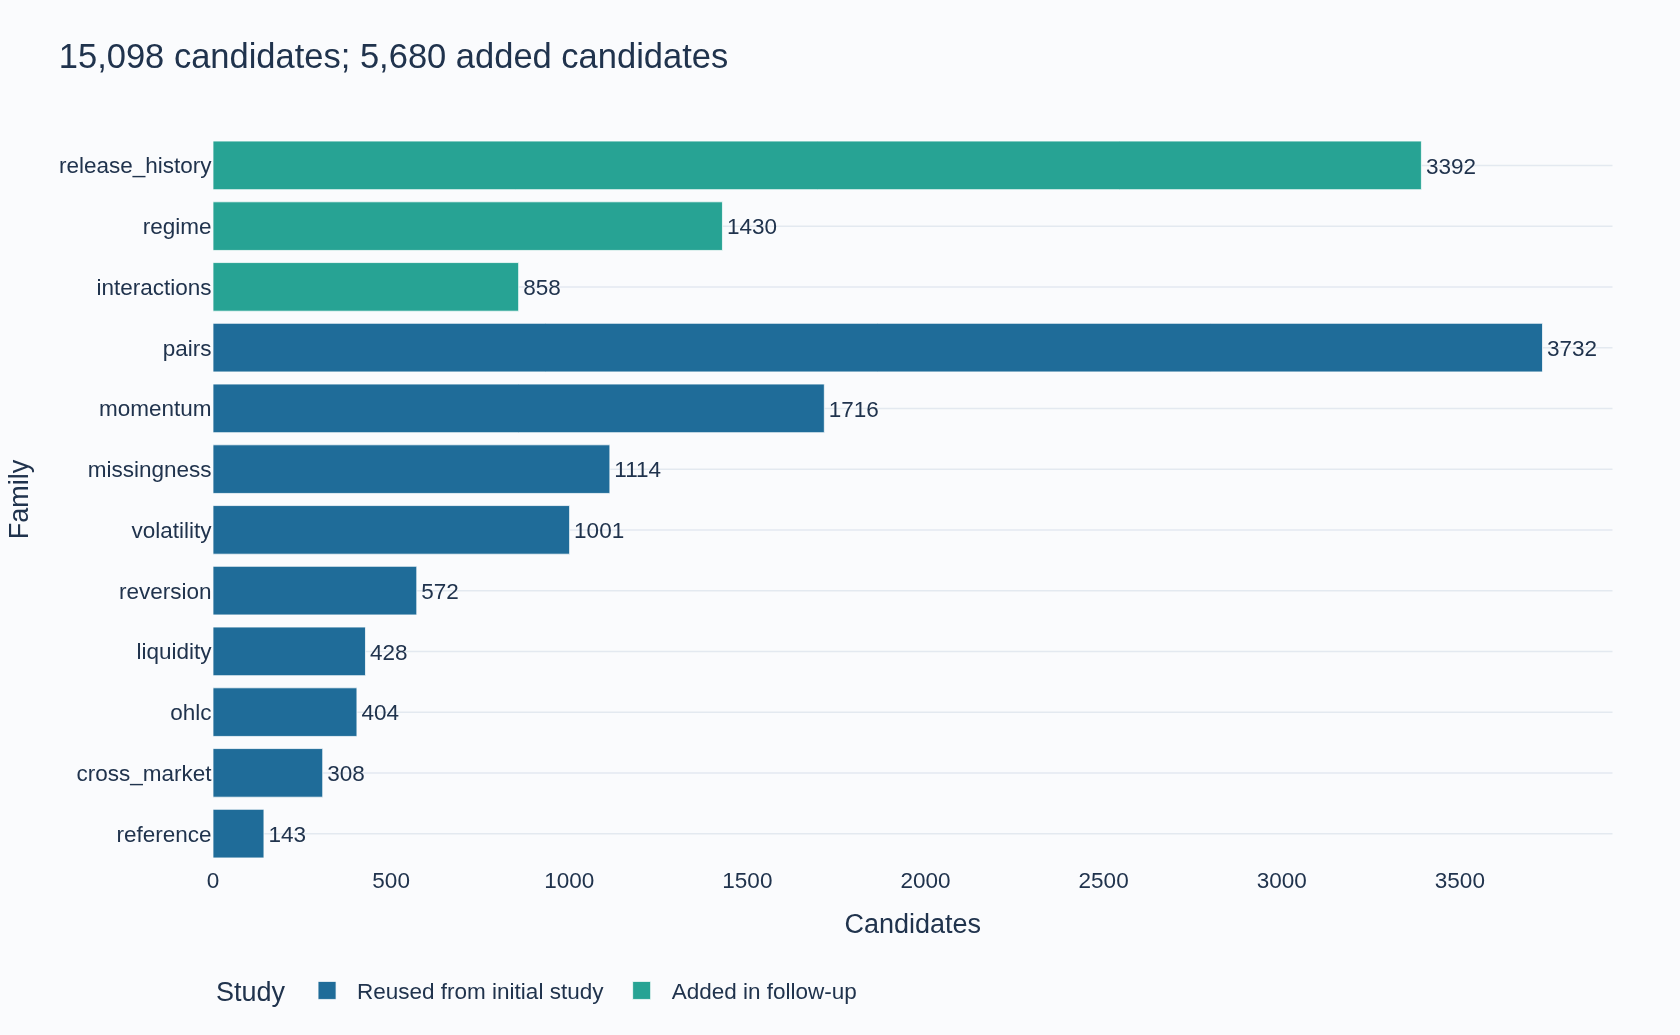

In [3]:
counts = pd.Series(study["family_counts"]).sort_values().rename_axis("Family").reset_index(name="Candidates")
counts["Study"] = np.where(counts.Family.isin(["regime", "interactions", "release_history"]), "Added in follow-up", "Reused from initial study")
fig = px.bar(counts, x="Candidates", y="Family", color="Study", orientation="h", text="Candidates",
             color_discrete_map={"Reused from initial study": "#1F6C99", "Added in follow-up": "#27A394"},
             title=f"{study['candidate_count']:,} candidates; {study['new_candidate_count']:,} added candidates")
fig.update_traces(textposition="outside")
fig.update_layout(legend={"orientation": "h", "y": -0.14})
show_figure(fig, root, "feature_families", 690)

## Hold model complexity fixed while changing representation

Each output can retain at most **24 features**, with training-only missingness, constant, duplicate, redundancy, and relevance checks. Stable screening requires the feature/target correlation to have the same sign in both training halves. Validation labels never enter the screener.

Aligned models see their own assets, exact pair, market context, and own released-label history. Structural models forecast asset returns first, then subtract components to preserve pair identities. Ridge alpha remains 100. A small fixed tree model checks nonlinear structure; automatic random early stopping is disabled.

The initial study used a shared 96-feature budget. Feature-attribution claims use matched controls inside this new 24-feature study.

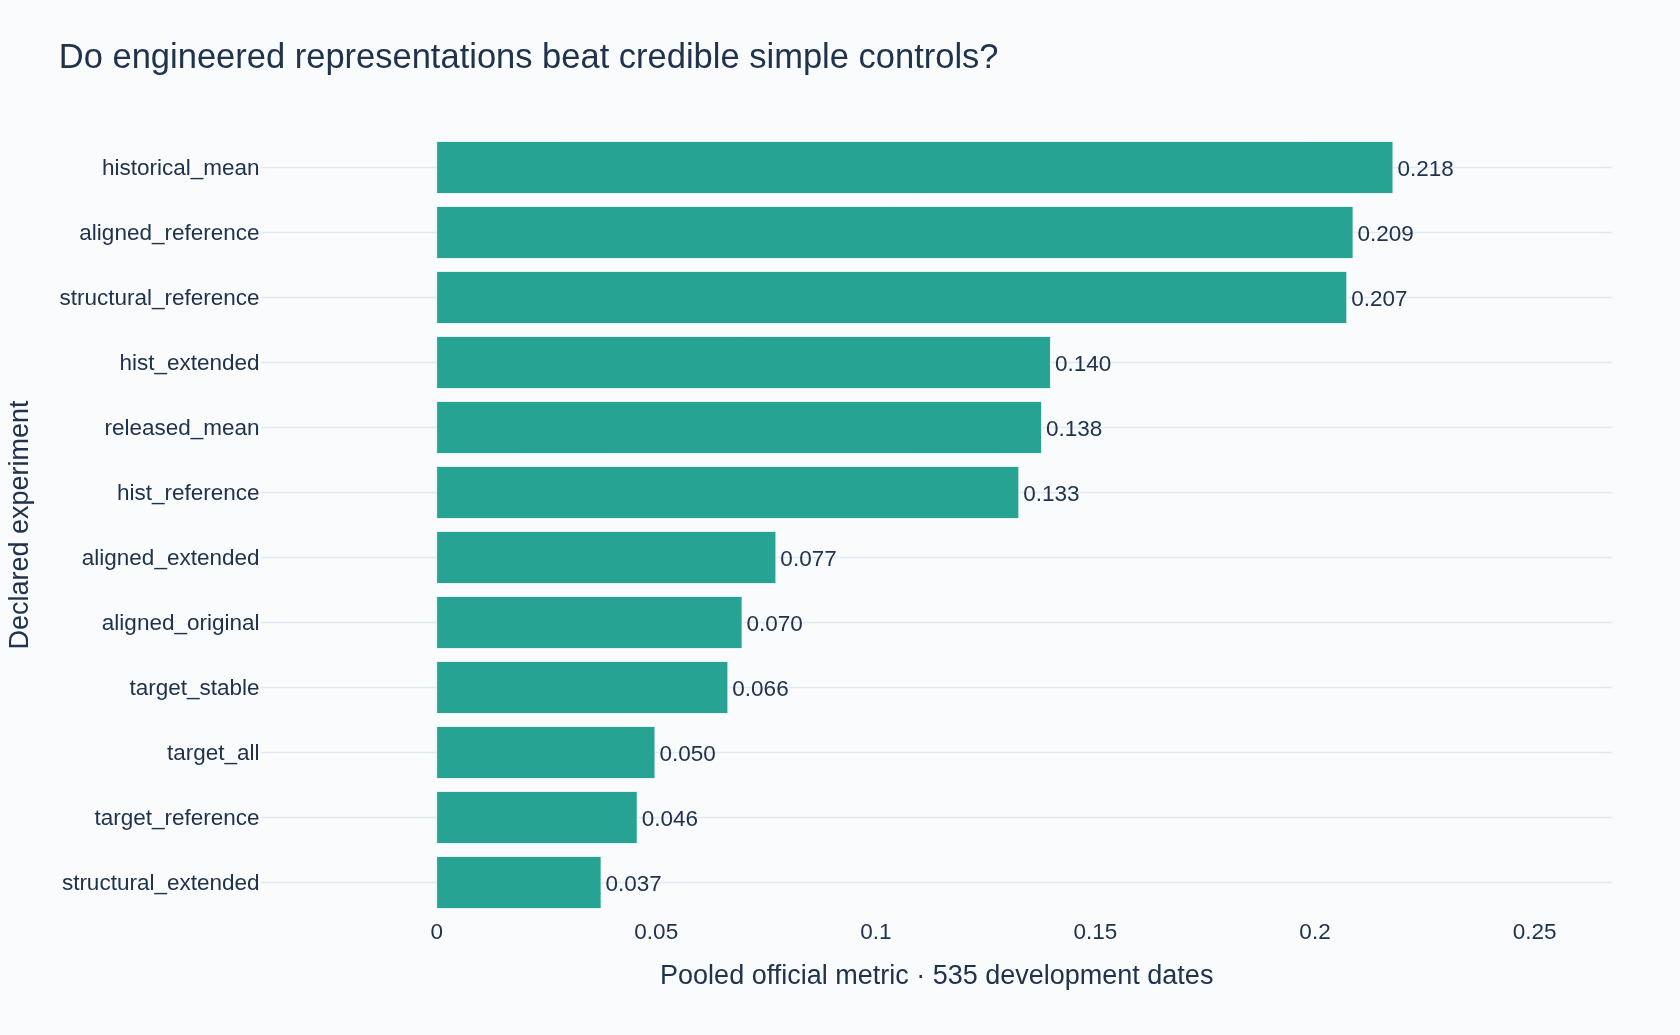

,variant,official_metric,mean_daily_rank_correlation,fold_metrics
0,historical_mean,0.2177,0.0458,"[0.1625498054219968, 0.1824882692897385, 0.296..."
1,aligned_reference,0.2087,0.0376,"[0.18846080346818364, 0.15181630184795522, 0.2..."
2,structural_reference,0.2072,0.0449,"[0.2046984676059178, 0.15098017890289422, 0.26..."
3,hist_extended,0.1398,0.0186,"[0.22812998923647995, 0.03725429947382911, 0.1..."
4,released_mean,0.1377,0.0314,"[0.04828282242250848, 0.11071876286325584, 0.2..."
5,hist_reference,0.1326,0.0168,"[0.06856313641909165, 0.08080476914422313, 0.2..."
12,aligned_extended,0.0772,0.0125,"[0.16464780319429506, -0.02305641120564604, 0...."
17,aligned_original,0.0695,0.0122,"[0.15130620130674452, -0.01551761340365714, 0...."
18,target_stable,0.0663,0.0109,"[0.12280555202259957, -0.011256661043576961, 0..."
19,target_all,0.0497,0.0089,"[0.14613819615240903, -0.12774538011787973, 0...."


In [4]:
main = comparison.loc[~comparison.variant.str.startswith("drop_")].sort_values("official_metric")
fig = px.bar(main, x="official_metric", y="variant", orientation="h", text_auto=".3f",
             title="Do engineered representations beat credible simple controls?")
fig.update_traces(marker_color="#27A394", textposition="outside")
fig.update_xaxes(range=[min(0, float(main.official_metric.min())) - 0.04, max(0, float(main.official_metric.max())) + 0.05])
fig.update_layout(xaxis_title="Pooled official metric · 535 development dates", yaxis_title="Declared experiment")
show_figure(fig, root, "ablation_scores", 690)
display(main[["variant", "official_metric", "mean_daily_rank_correlation", "fold_metrics"]].sort_values("official_metric", ascending=False).round(4))

## Matched comparisons separate feature value from other changes

The official metric is mean daily cross-sectional Spearman correlation divided by its population standard deviation. Feature value is a difference from a matched reference, not merely a high standalone score.

The chart shows simultaneous 95% bounds over the study's declared comparisons using 20-date blocks and 2,000 paired resamples within folds. Reports also include conditional intervals and 10-/40-date sensitivity. These bounds do not include fresh feature searches, refitting uncertainty, or all prior adaptive decisions.

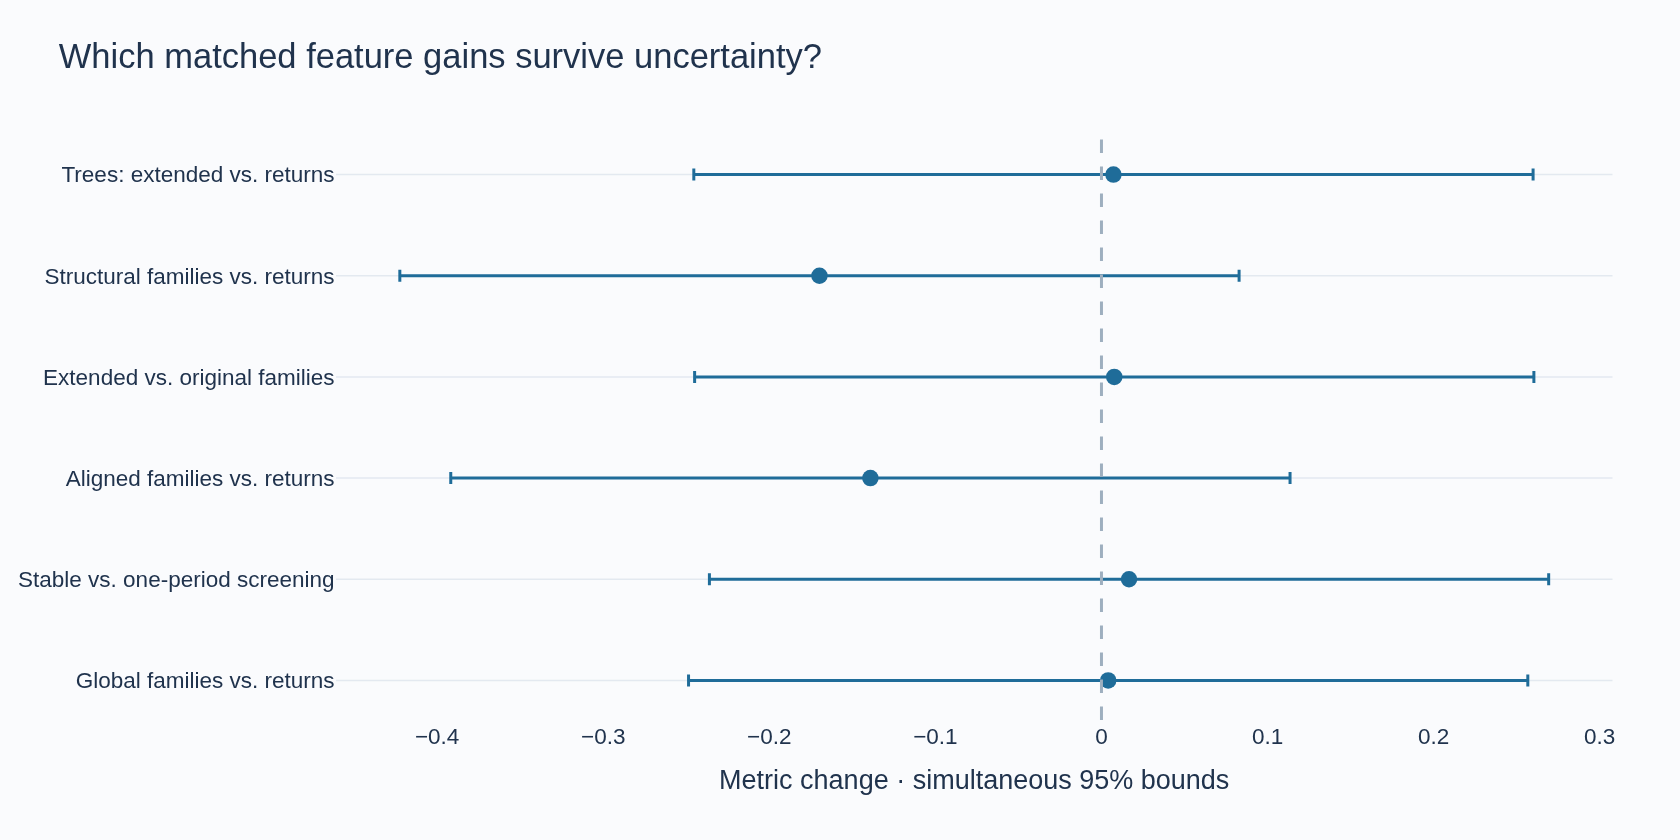

,Comparison,delta,conditional_95_interval,simultaneous_95_interval
62,Global families vs. returns,0.004041,"[-0.10862243826086511, 0.11755883184525671]","[-0.24862205260731507, 0.2567041962572768]"
63,Stable vs. one-period screening,0.016600,"[-0.05868773373109757, 0.09586012101072447]","[-0.23606331174358897, 0.2692629371210029]"
64,Aligned families vs. returns,-0.139124,"[-0.32070014281458104, 0.039068977013302]","[-0.3917869415139999, 0.11353930735059198]"
65,Extended vs. original families,0.007697,"[-0.0793185128991259, 0.09428367205118715]","[-0.2449658463006456, 0.26036040256394627]"
66,Structural families vs. returns,-0.169798,"[-0.35356182350299403, 0.02018627162469122]","[-0.4224609347394015, 0.08286531412519041]"
67,Trees: extended vs. returns,0.007213,"[-0.16226260547976623, 0.17329660440397873]","[-0.24545026298063968, 0.2598759858839522]"


In [5]:
bounds = pd.DataFrame(study["paired_intervals"])
labels = {
    ("target_all", "target_reference"): "Global families vs. returns",
    ("target_stable", "target_all"): "Stable vs. one-period screening",
    ("aligned_original", "aligned_reference"): "Aligned families vs. returns",
    ("aligned_extended", "aligned_original"): "Extended vs. original families",
    ("structural_extended", "structural_reference"): "Structural families vs. returns",
    ("hist_extended", "hist_reference"): "Trees: extended vs. returns",
}
matched = bounds.loc[(bounds.block_dates == 20) & bounds.apply(lambda r: (r.variant, r.reference) in labels, axis=1)].copy()
matched["Comparison"] = matched.apply(lambda r: labels[(r.variant, r.reference)], axis=1)
lo = matched.simultaneous_95_interval.map(lambda a: a[0])
hi = matched.simultaneous_95_interval.map(lambda a: a[1])
fig = go.Figure(go.Scatter(x=matched.delta, y=matched.Comparison, mode="markers", marker={"size": 11, "color": "#1F6C99"},
    error_x={"type": "data", "symmetric": False, "array": hi - matched.delta, "arrayminus": matched.delta - lo}))
fig.add_vline(x=0, line_dash="dash", line_color="#9EAFBF")
fig.update_layout(title="Which matched feature gains survive uncertainty?", xaxis_title="Metric change · simultaneous 95% bounds")
show_figure(fig, root, "ablation_uncertainty", 560)
display(matched[["Comparison", "delta", "conditional_95_interval", "simultaneous_95_interval"]])

## Conditional ablations: remove one family and refit

Every non-reference family is removed from the extended aligned representation while the same screening rule and estimator are refit. Positive deltas favor the full representation; negative deltas favor removal. An ablation measures the whole pipeline's dependence on a family, including replacement features selected after removal.

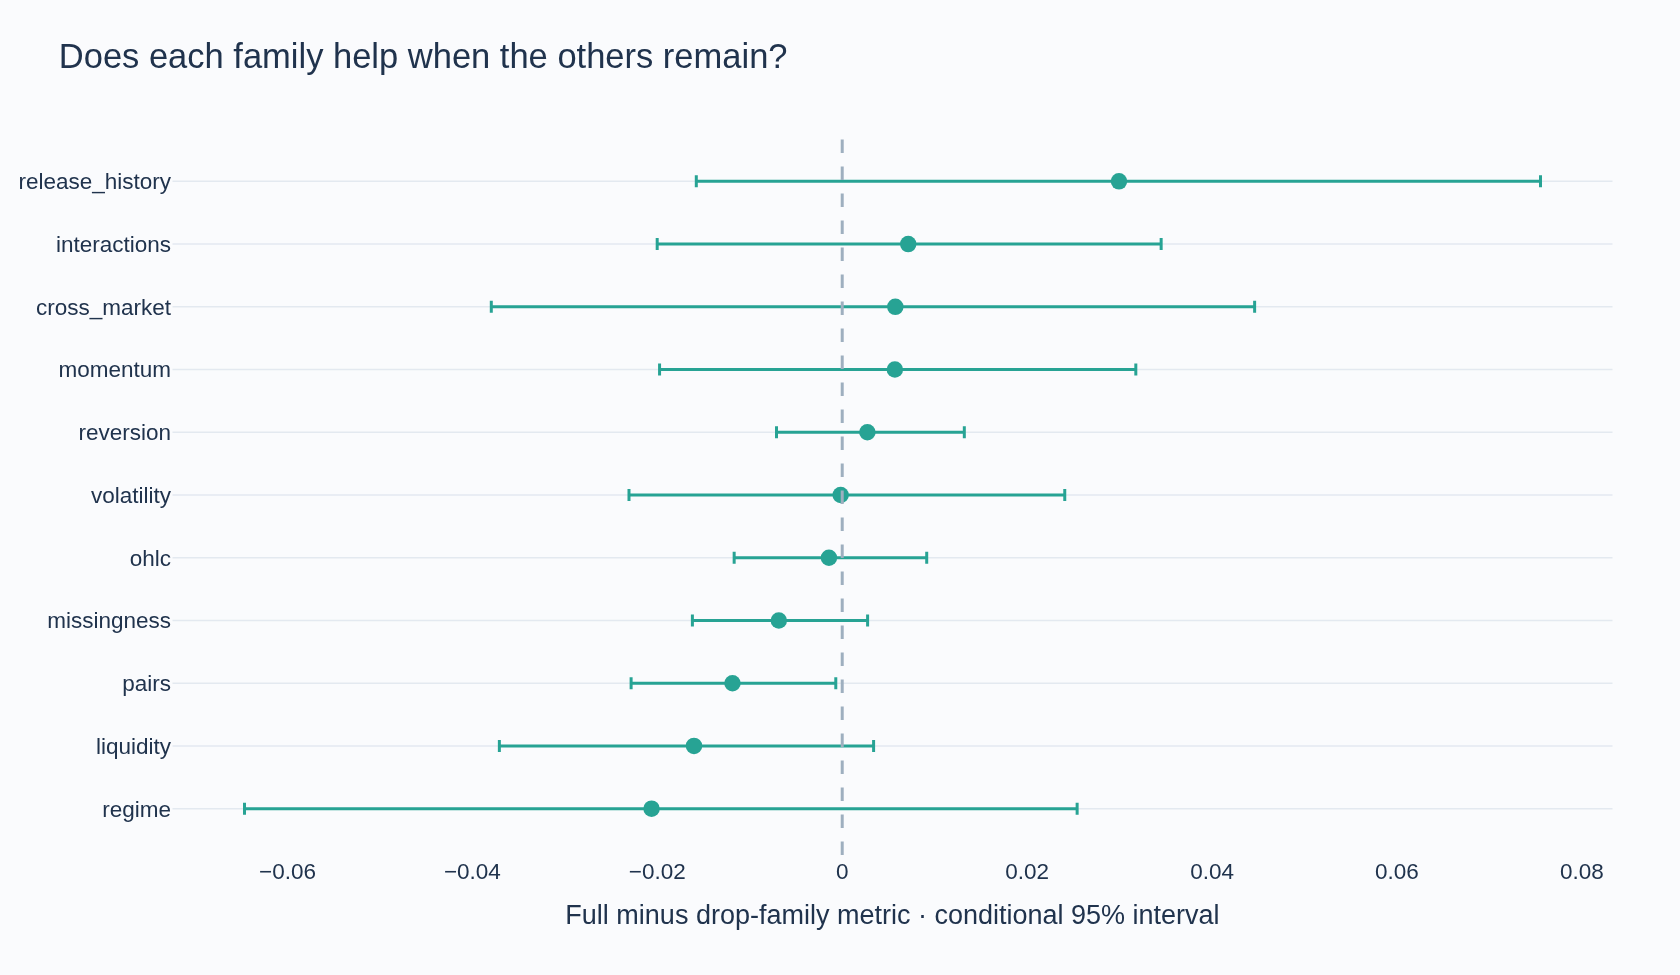

In [6]:
drops = bounds.loc[(bounds.block_dates == 20) & (bounds.variant == "aligned_extended") & bounds.reference.str.startswith("drop_")].sort_values("delta").copy()
drops["Family"] = drops.reference.str.removeprefix("drop_")
lo = drops.conditional_95_interval.map(lambda a: a[0])
hi = drops.conditional_95_interval.map(lambda a: a[1])
fig = go.Figure(go.Scatter(x=drops.delta, y=drops.Family, mode="markers", marker={"size": 11, "color": "#27A394"},
    error_x={"type": "data", "symmetric": False, "array": hi - drops.delta, "arrayminus": drops.delta - lo}))
fig.add_vline(x=0, line_dash="dash", line_color="#9EAFBF")
fig.update_layout(title="Does each family help when the others remain?", xaxis_title="Full minus drop-family metric · conditional 95% interval")
show_figure(fig, root, "conditional_ablations", 650)

## Stability across time and horizons

All variants use the same expanding folds. The final validation block is five dates shorter to enforce the holdout boundary. A pooled gain that reverses in a period needs additional evidence. Horizon diagnostics report eligible dates separately; they do not replace the primary metric across all observed targets.

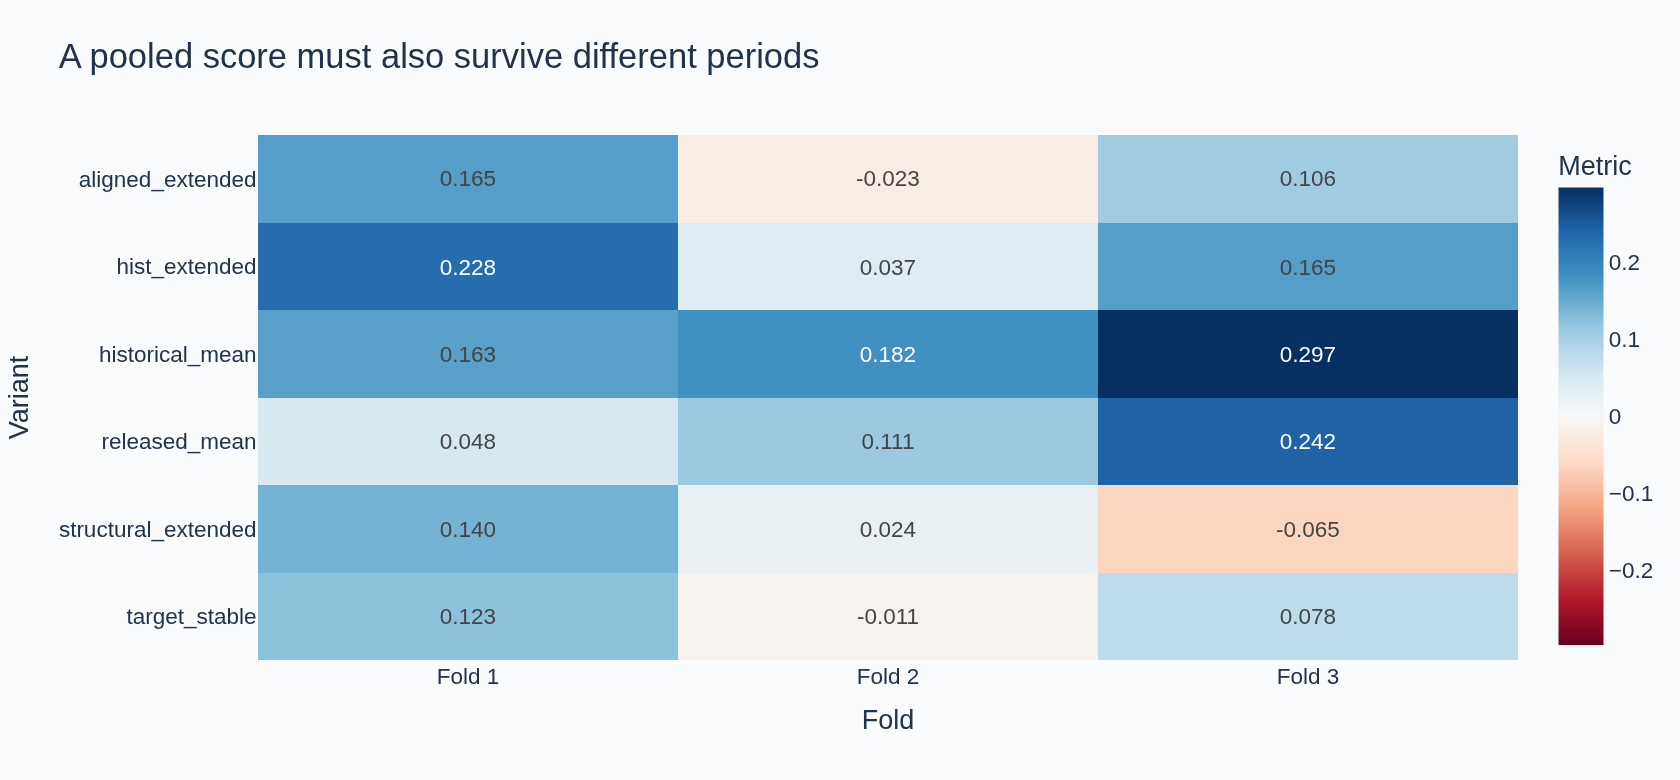

**Horizon diagnostics for the earlier study point-estimate leader:** historical_mean

,Fold,Horizon,eligible_dates,excluded_dates,mean_daily_rank_correlation,official_metric
0,1,1,180,0,0.0328,0.1520
1,1,2,180,0,0.0223,0.0840
2,1,3,180,0,0.0365,0.1425
3,1,4,179,1,0.0135,0.0690
4,2,1,179,1,0.0332,0.1306
5,2,2,178,2,0.0366,0.1334
6,2,3,178,2,0.0470,0.1773
7,2,4,179,1,0.0395,0.1848
8,3,1,175,0,0.0677,0.2397
9,3,2,175,0,0.0940,0.2926


In [7]:
focus = ["historical_mean", "released_mean", "target_stable", "aligned_extended", "structural_extended", "hist_extended"]
rows = [{"Variant": r["variant"], "Fold": f"Fold {r['fold'] + 1}", "Metric": r["official_metric"]}
        for r in study["results"] if r["variant"] in focus]
matrix = pd.DataFrame(rows).pivot(index="Variant", columns="Fold", values="Metric")
fig = px.imshow(matrix, text_auto=".3f", color_continuous_scale="RdBu", color_continuous_midpoint=0, aspect="auto",
                title="A pooled score must also survive different periods", labels={"color": "Metric"})
show_figure(fig, root, "fold_stability", 520)
best_name = study["comparison"][0]["variant"]
horizon_rows = [{"Fold": r["fold"] + 1, "Horizon": h, **metrics} for r in study["results"] if r["variant"] == best_name for h, metrics in r["horizon_metrics"].items()]
display(Markdown(f"**Horizon diagnostics for the earlier study point-estimate leader:** {best_name}"))
display(pd.DataFrame(horizon_rows).round(4))

## Model reliance and selection stability

Joint block permutation disrupts a family's date alignment while preserving within-date structure across targets. The model stays frozen. The chart averages changes in **fold-level** scores across five perturbations per fold. It is not a pooled official score or a causal importance estimate. Correlated groups can substitute for one another, and perturbations can leave the observed data distribution.

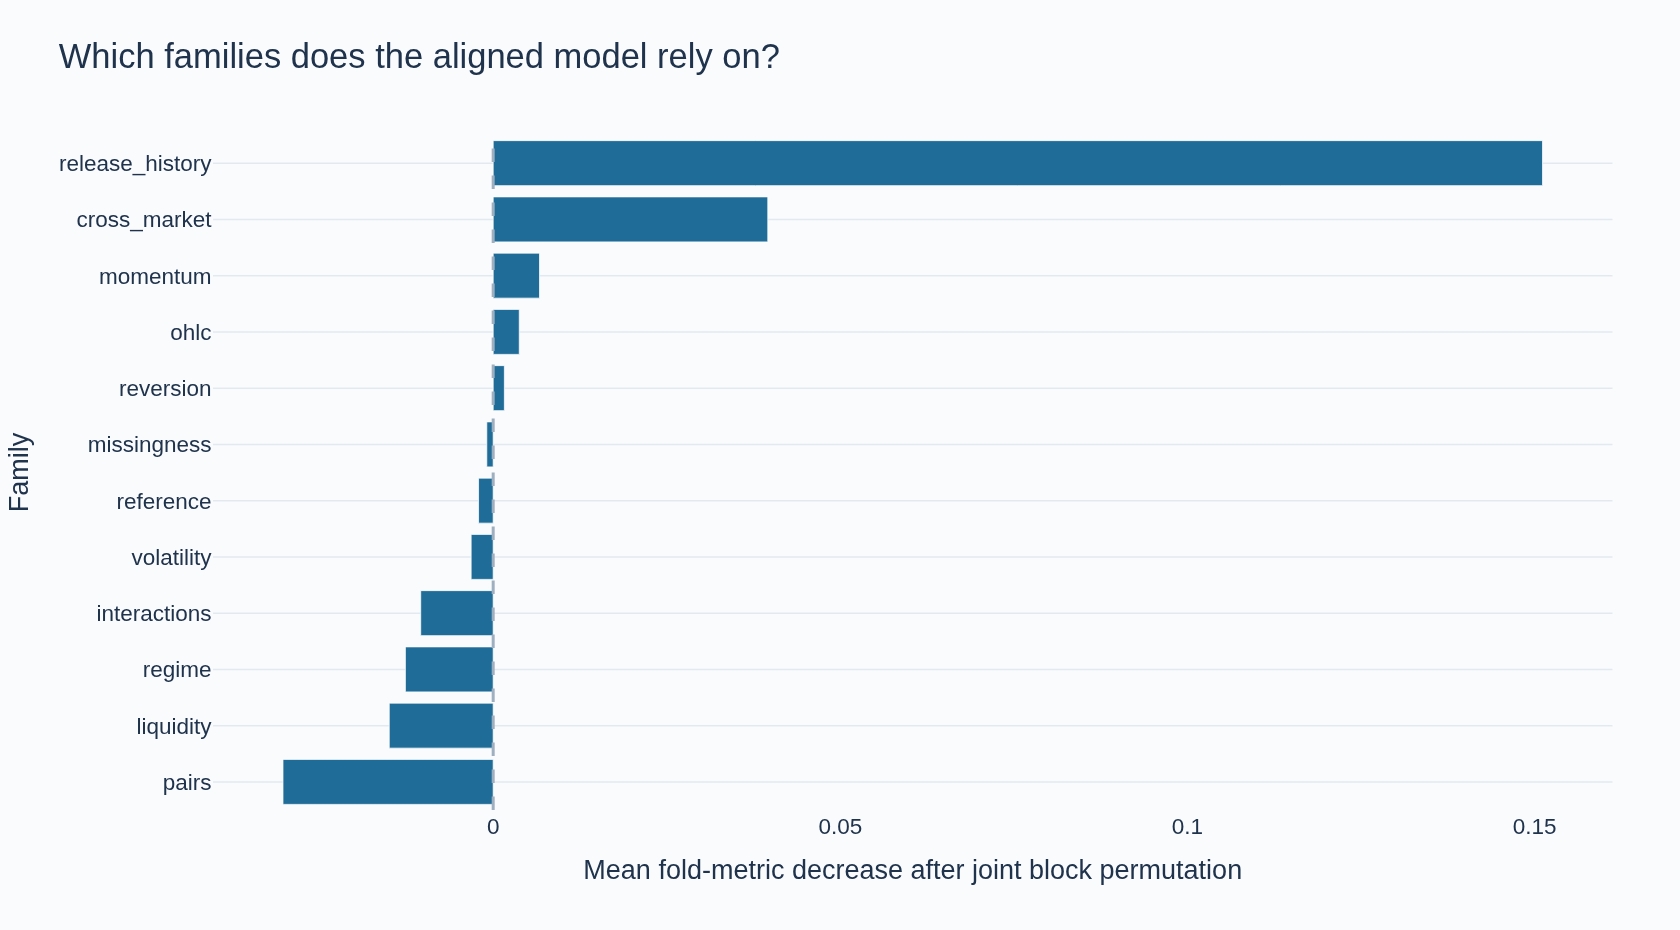

In [8]:
permutation_rows = []
for fold, groups in study["group_permutation"].items():
    for family, stats in groups.items():
        permutation_rows.extend({"Fold": fold, "Family": family, "Metric drop": value} for value in stats["metric_drop_repetitions"])
importance = pd.DataFrame(permutation_rows).groupby("Family")["Metric drop"].mean().sort_values().reset_index()
fig = px.bar(importance, x="Metric drop", y="Family", orientation="h", title="Which families does the aligned model rely on?")
fig.update_traces(marker_color="#1F6C99")
fig.add_vline(x=0, line_dash="dash", line_color="#9EAFBF")
fig.update_layout(xaxis_title="Mean fold-metric decrease after joint block permutation")
show_figure(fig, root, "group_permutation", 620)

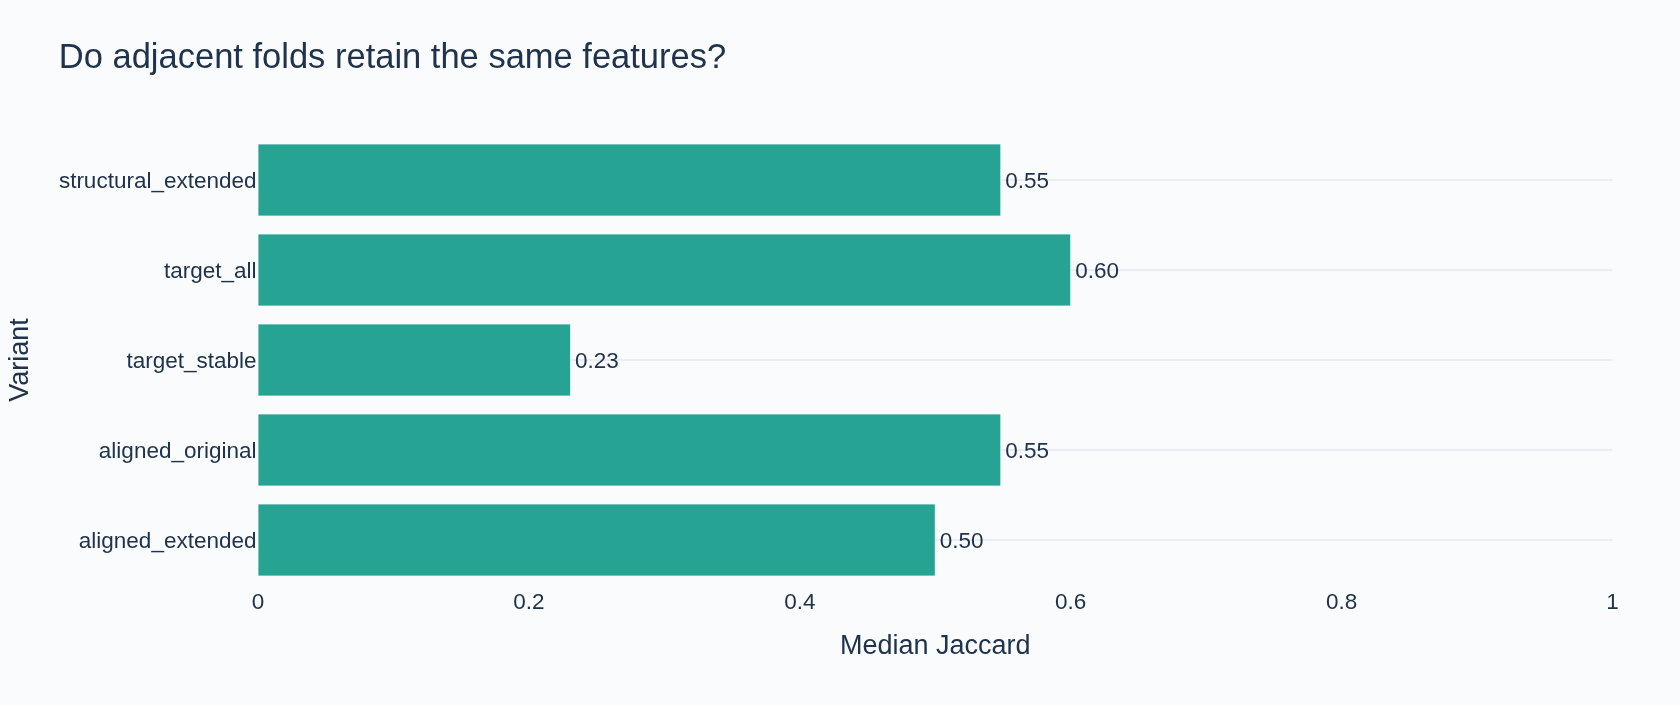

,Last-fold aligned screen
candidate_output_assignments,61598.0
retained_output_assignments,10176.0
rejected_output_assignments,51422.0
unique_retained_features,4241.0
retained_per_output_min,24.0
retained_per_output_median,24.0
retained_per_output_max,24.0


,Rejected assignments
unstable_sign_or_insufficient_history,27447
feature_budget,18687
duplicate,4906
constant,268
correlated,114


In [9]:
stability = pd.DataFrame([{"Variant": r["variant"], "Median Jaccard": r["selection_stability"]["median_jaccard"]}
    for r in study["comparison"] if r["variant"] in ["target_all", "target_stable", "aligned_original", "aligned_extended", "structural_extended"]])
fig = px.bar(stability, x="Median Jaccard", y="Variant", orientation="h", text_auto=".2f", title="Do adjacent folds retain the same features?")
fig.update_traces(marker_color="#27A394", textposition="outside")
fig.update_xaxes(range=[0, 1])
show_figure(fig, root, "selection_stability", 470)
last = next(r for r in study["results"] if r["variant"] == "aligned_extended" and r["fold"] == 2)
screening = last["screening"]
display(pd.Series({key: screening[key] for key in ["candidate_output_assignments", "retained_output_assignments", "rejected_output_assignments", "unique_retained_features", "retained_per_output_min", "retained_per_output_median", "retained_per_output_max"]}, name="Last-fold aligned screen").to_frame())
display(pd.Series(screening["rejection_reasons"], name="Rejected assignments").sort_values(ascending=False).to_frame())

Counts summed over target-specific screens are **feature/output assignments**. The same generated feature can enter several models. Unique candidates, unique retained features, and assignments are different quantities. A budget rejection does not prove absence of predictive signal.

In [10]:
best = study["comparison"][0]
mean_control = next(r for r in study["comparison"] if r["variant"] == "historical_mean")
display(Markdown(f"**Earlier study leader:** {best['variant']} at **{best['official_metric']:.4f}**. Frozen training means score **{mean_control['official_metric']:.4f}** on the same dates.\n\nCompleted **{study['experiments_completed']} fold/representation experiments** using **{study['candidate_count']:,} candidates**, while preserving all 30 initial experiments. Feature gate: **open**."))

**Earlier study leader:** historical_mean at **0.2177**. Frozen training means score **0.2177** on the same dates.

Completed **69 fold/representation experiments** using **15,098 candidates**, while preserving all 30 initial experiments. Feature gate: **open**.

## What the earlier target-aware study established

Frozen training means lead at **0.2177**; aligned return-only Ridge is close at **0.2087**. Its difference from the mean control is **−0.0091**, with a conditional 95% interval of **[−0.0580, +0.0366]**. This is evidence to keep a strong prior benchmark in every future experiment.

The three added families improve aligned Ridge by only **+0.0077**, with interval **[−0.0793, +0.0943]**. Released-label history has the largest positive conditional ablation estimate (**+0.0299**), but its interval includes zero. Pair removal helps under a conditional interval, but does not survive simultaneous comparison bounds. No positive matched feature gain is established by the simultaneous bounds.

Richer aligned models reverse sign in the middle fold, and the extended structural model reverses in the last fold. These failures argue for investigating target priors, scale, and residual structure before broad tuning. More generated features are not evidence of more usable signal.

## Transition to the domain study

Keep the feature gate open. This study addresses credible mean controls, output-specific screening, economic routing, structural forecasts, longer risk regimes, released-label histories, conditional ablations, nonlinear controls, and block-size sensitivity. It does not establish diminishing returns for every plausible feature avenue.

Next decisions should follow the measured weaknesses: distinguish cross-sectional prior information from useful time-varying features, assess target/horizon normalization and robust residual representations, and test surviving interactions with nested temporal selection. External data require a defensible calendar mapping, source vintages, and appropriate rights; date IDs must not receive guessed calendar dates. Final optimization and reserved-holdout evaluation remain gated.

[Research protocol](../docs/research-protocol.md) · [Aggregate evidence](../reports/feature_study.json) · [Official metric](https://www.kaggle.com/code/metric/mitsui-co-commodity-prediction-metric).

## Domain study: separate target priors from changing market information

The preceding study motivated a stronger question: can economic features forecast the residual around each target's training mean? This follow-up keeps those earlier results intact and tests 13 domain families in a shared, risk-normalized date/target model.

[Domain research ledger and primary sources](../docs/domain-feature-research.md) explains instrument conventions, mathematical definitions, and the data needed for remaining avenues. **Feature gate: open.**

In [11]:
domain_rows = pd.DataFrame([{"Variant": name, "Metric": value["official_metric"], "Fold scores": value["fold_scores"], "Residual weights": value["residual_weights"]} for name, value in domain["summaries"].items()])
inventory = domain["inventory"]
display(pd.Series({"Pooled templates": inventory["templates"], "Instantiated source series": inventory["source_series_count"], "Target-template assignments": inventory["target_template_assignments"], "New fitted models (including inner fits)": domain["new_fitted_models"], "Outer evaluations (including controls)": domain["outer_evaluations"], "Validation dates": domain["validation_dates"]}, name="Domain study inventory").to_frame())
display(Markdown(inventory["counting_note"]))

,Domain study inventory
Pooled templates,380
Instantiated source series,29917
Target-template assignments,161120
New fitted models (including inner fits),279
Outer evaluations (including controls),102
Validation dates,535


Templates are pooled input columns. Source series count instantiated intermediate market/target series before projection, including controls and transformations of earlier features. Target-template assignments include shared and structurally unavailable values; none of these counts is a claim of independent signals or newly unique features.

### Translate mechanisms into observable features

Trend shape, tail risk, activity, overnight versus intraday paths, and stale observations describe the individual market. Factor-relative innovations, macro-market links, FX currency strengths, contract/settlement differences, and pair dynamics describe relationships. Release-safe historical pools, horizon structure, and strictly trailing latent factors describe shared prediction structure.

JPY prices are divided by USD/JPY before comparison with dollar movements. JPX/GLD and futures-contract differences remain **relative-price proxies**: missing delivery curves, units, timestamps, and transaction costs prevent carry or arbitrage claims. No guessed calendar, revised fundamentals, future holdings, or retrospective news enter predictors.

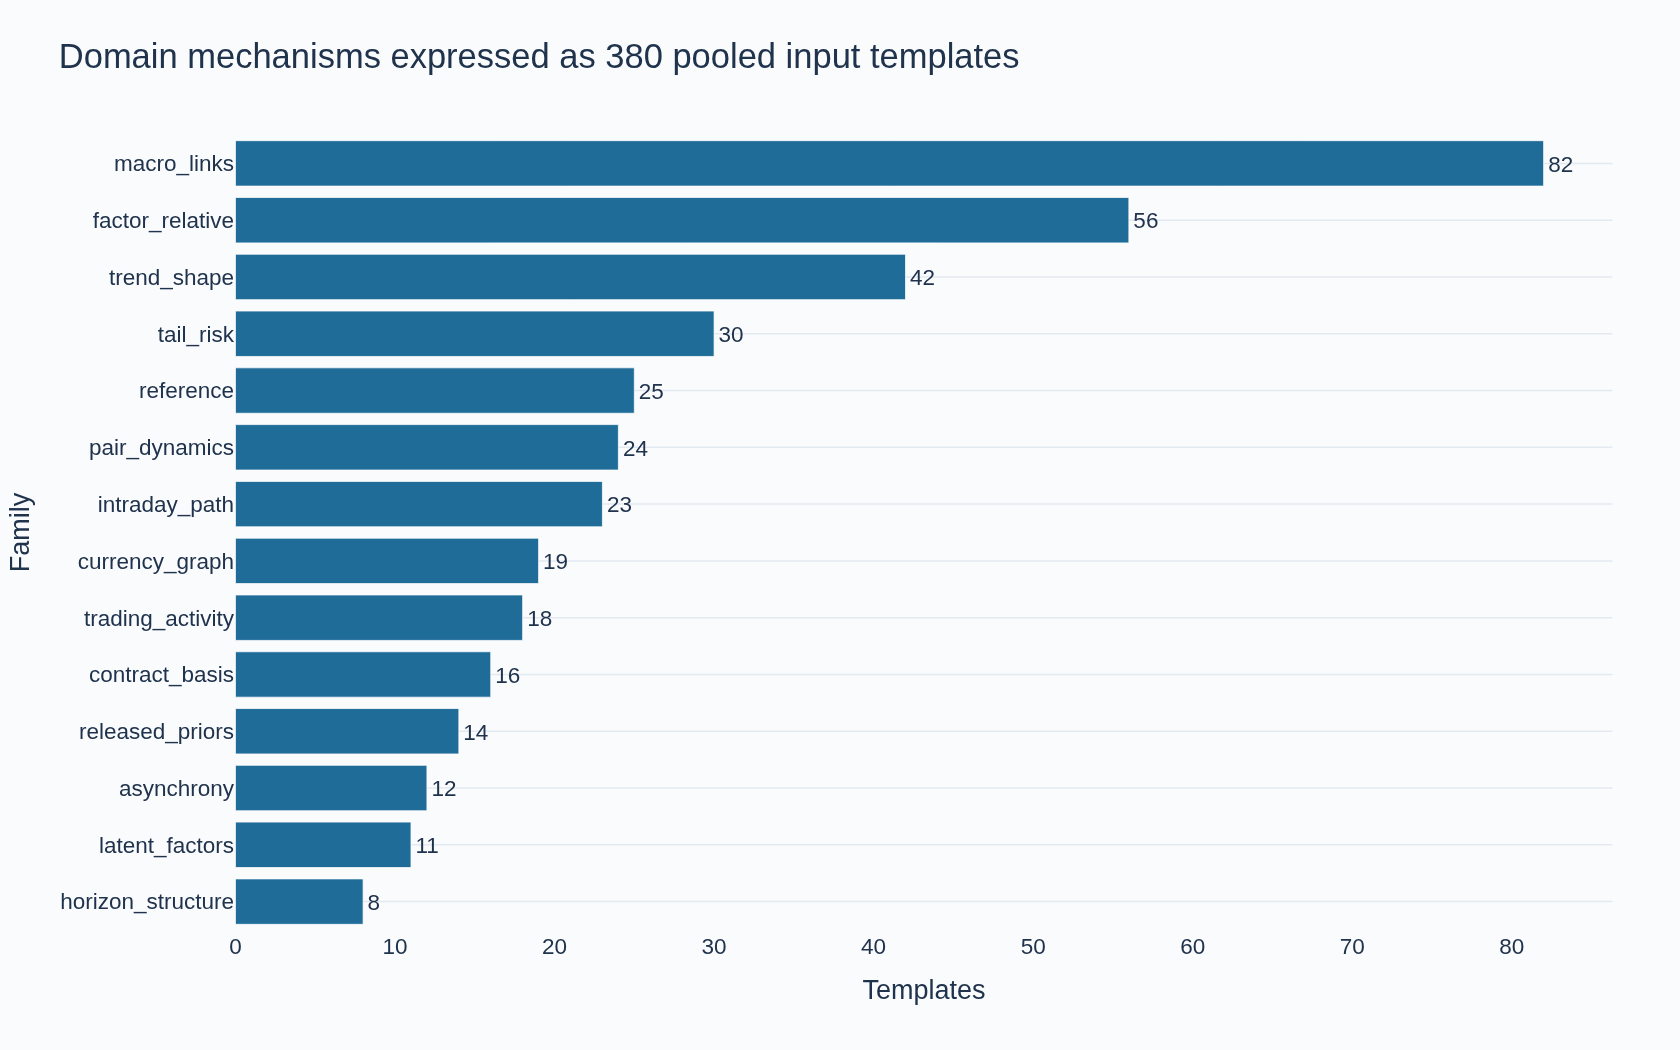

In [12]:
family_counts = pd.Series(inventory["family_templates"]).sort_values().rename_axis("Family").reset_index(name="Templates")
fig = px.bar(family_counts, x="Templates", y="Family", orientation="h", text="Templates", title="Domain mechanisms expressed as 380 pooled input templates")
fig.update_traces(marker_color="#1F6C99", textposition="outside")
show_figure(fig, root, "domain_family_templates", 700)

### Fix model settings and put residual calibration inside training

Every date has equal total fitting weight. Each fit estimates target mean and risk, imputes and scales inputs, and selects at most 64 templates using only its training interval. A fixed Ridge penalty and fixed small histogram-tree configuration limit model-search confounding. Targets are standardized and clipped for fitting; evaluation uses unchanged observed targets.

Two purged 126-date inner validation blocks choose a residual weight from 0, .05, .1, .25, .5, or 1. A zero means the inner evidence chose the historical-mean fallback. **Raw variants always use weight 1**, exposing feature behavior that shrinkage might hide. All outer validation dates remain outside these decisions.

The 31 fitted variants include a reference, 13 single-family additions, all families, sign-stable screening, 13 removals, and two tree controls. Historical, graph-projected, and winsorized means test alternative priors.

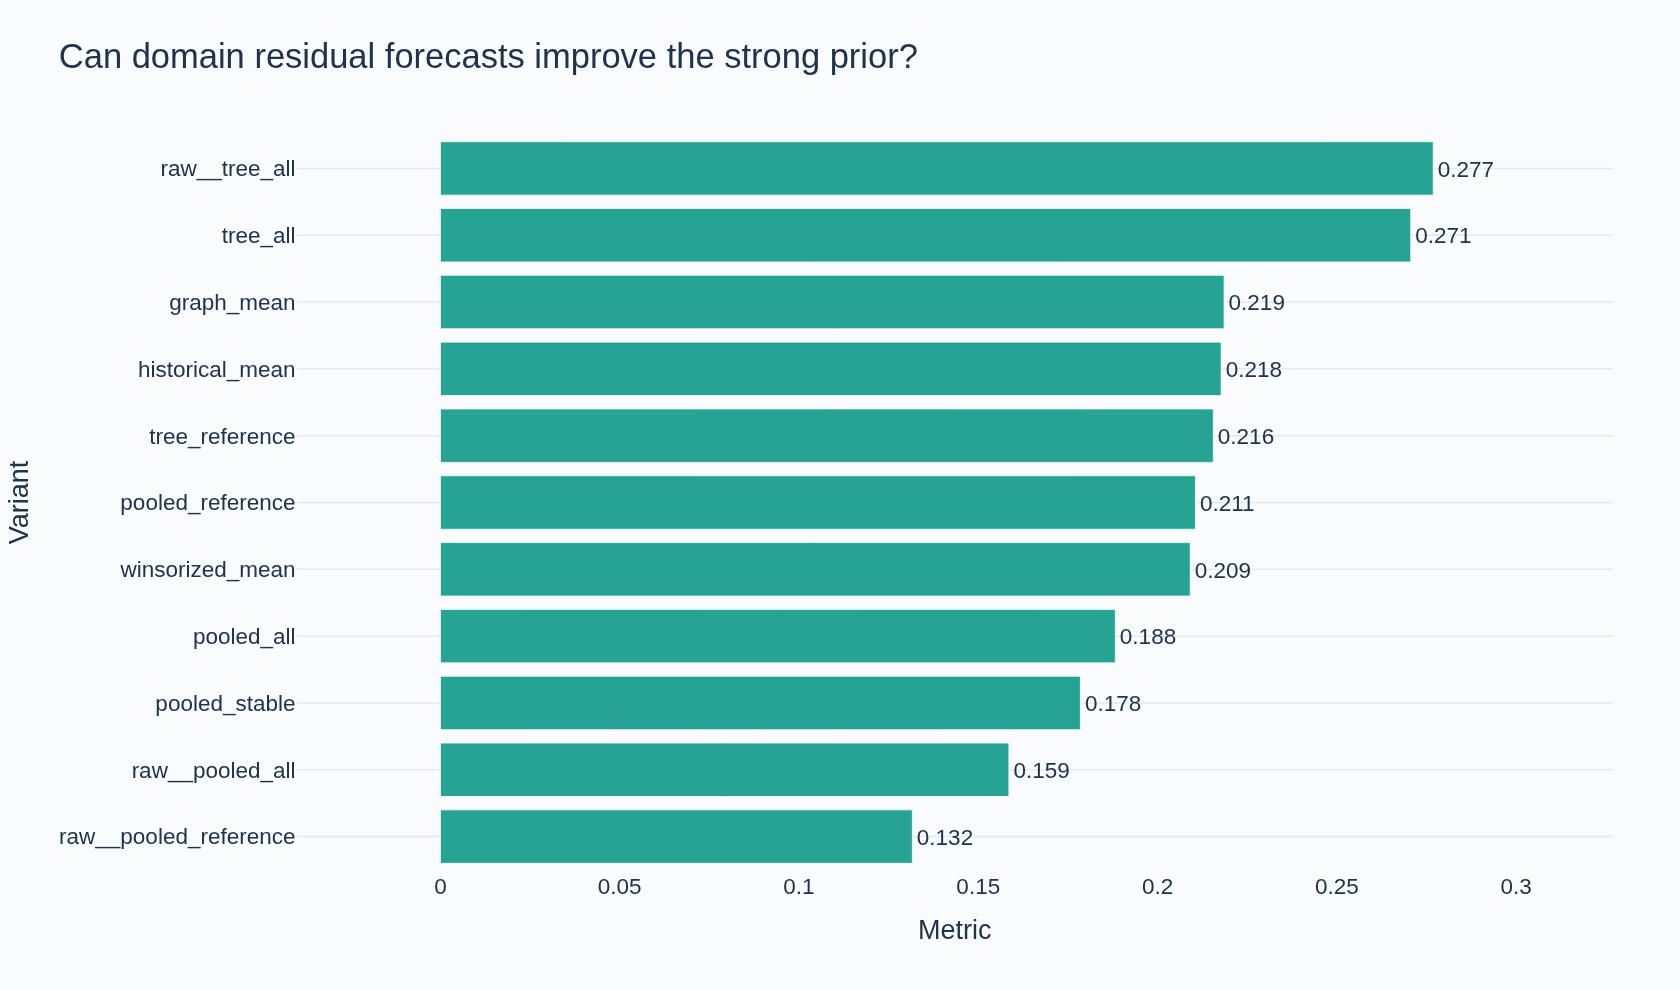

,Variant,Metric,Fold scores,Residual weights
60,raw__tree_all,0.27689,"[0.348696570690272, 0.11147004877633712, 0.402...","[1.0, 1.0, 1.0]"
62,tree_all,0.27061,"[0.348696570690272, 0.11147004877633712, 0.377...","[1.0, 1.0, 0.5]"
26,graph_mean,0.21856,"[0.1682421380744304, 0.18336490457535354, 0.29...","[0, 0, 0]"
27,historical_mean,0.21774,"[0.1625498054219968, 0.1824882692897385, 0.296...","[0, 0, 0]"
63,tree_reference,0.21556,"[0.1601678548389069, 0.17848568651184174, 0.29...","[1.0, 0.1, 0.0]"
29,pooled_reference,0.21057,"[0.15210709294864544, 0.1824882692897385, 0.29...","[1.0, 0.0, 0.0]"
64,winsorized_mean,0.20911,"[0.16709463397129035, 0.17261050119412968, 0.2...","[0, 0, 0]"
28,pooled_all,0.18823,"[0.2990979686189526, -0.03127677962017847, 0.3...","[1.0, 0.5, 0.05]"
30,pooled_stable,0.17848,"[0.2712093529399895, -0.03528252705282996, 0.3...","[1.0, 0.5, 0.05]"
57,raw__pooled_all,0.15854,"[0.2990979686189526, -0.05433269637256464, 0.2...","[1.0, 1.0, 1.0]"


In [13]:
focus_names = ["historical_mean", "graph_mean", "winsorized_mean", "pooled_reference", "pooled_all", "pooled_stable", "tree_reference", "tree_all", "raw__pooled_reference", "raw__pooled_all", "raw__tree_all"]
focus = domain_rows.loc[domain_rows.Variant.isin(focus_names)].sort_values("Metric")
fig = px.bar(focus, x="Metric", y="Variant", orientation="h", text_auto=".3f", title="Can domain residual forecasts improve the strong prior?")
fig.update_traces(marker_color="#27A394", textposition="outside")
fig.update_xaxes(range=[min(0,focus.Metric.min())-.04,max(0,focus.Metric.max())+.05])
show_figure(fig, root, "domain_model_scores", 660)
display(focus.sort_values("Metric",ascending=False).round(5))

### Each family receives both an addition and a removal test

An addition compares reference-plus-family with reference alone. A removal compares all families with the representation lacking that family. Positive values favor including the family. Screening is refit in each candidate pool, so a removal can expose substitute features. The plot uses **raw weight-1 models** to isolate the unshrunk feature pipeline; the table includes the nested-calibrated versions.

Error bars are simultaneous 95% bounds across all declared comparisons in this study, using 20-date blocks and 2,000 paired resamples within folds. Ten- and forty-date sensitivity and conditional intervals remain in the aggregate report. Repeated development research prevents a confirmatory interpretation.

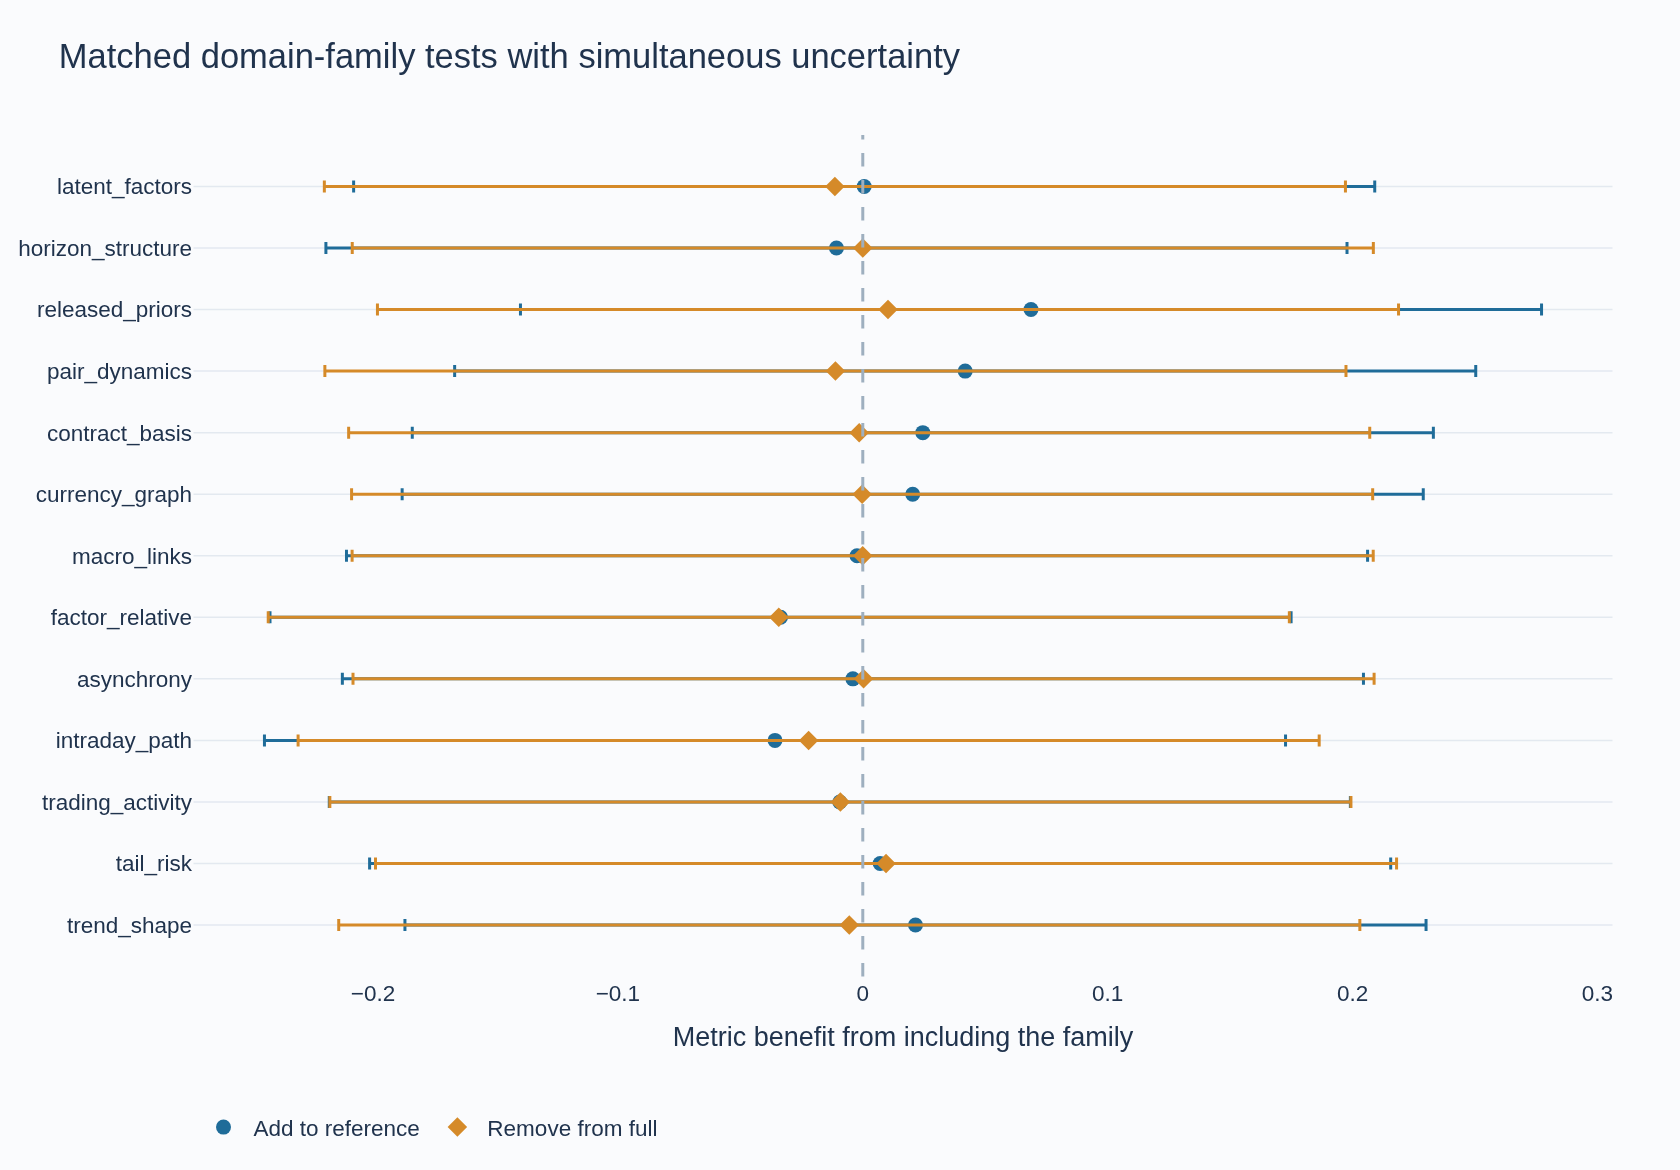

,variant,reference,delta,conditional_95_interval,simultaneous_95_interval
122,pooled_reference,historical_mean,-0.007172,"[-0.08362818603200306, 0.07071869785567043]","[-0.2156710518358059, 0.20132631671890508]"
150,pooled_all,historical_mean,-0.029506,"[-0.162332971256219, 0.09367074644411447]","[-0.23800435546299675, 0.17899301309171423]"
182,tree_all,historical_mean,0.052873,"[-0.04977298081682865, 0.15315442764861387]","[-0.15562596927399486, 0.2613713992807161]"
184,graph_mean,historical_mean,0.000817,"[-0.008544766746714061, 0.010906959649308655]","[-0.20768121069838777, 0.2093161578563232]"
212,pooled_all,pooled_reference,-0.022333,"[-0.1274720198525781, 0.07515569543856011]","[-0.23083198790454634, 0.18616538065016464]"
214,tree_all,tree_reference,0.055051,"[-0.0292015608098686, 0.14014962178946455]","[-0.15344778217296143, 0.2635495863817495]"


In [14]:
domain_bounds = pd.DataFrame(domain["comparisons"])
matched = []
for r in domain["comparisons"]:
    if r["block_dates"] != 20:
        continue
    if r["variant"].startswith("raw__add_") and r["reference"] == "raw__pooled_reference":
        matched.append({**r,"Family":r["variant"].removeprefix("raw__add_"),"Test":"Add to reference"})
    elif r["variant"] == "raw__pooled_all" and r["reference"].startswith("raw__drop_"):
        matched.append({**r,"Family":r["reference"].removeprefix("raw__drop_"),"Test":"Remove from full"})
matched = pd.DataFrame(matched)
fig = go.Figure()
for label, color, symbol in [("Add to reference","#1F6C99","circle"),("Remove from full","#D58A29","diamond")]:
    group = matched.loc[matched.Test == label]
    lo = group.simultaneous_95_interval.map(lambda x:x[0]); hi = group.simultaneous_95_interval.map(lambda x:x[1])
    fig.add_trace(go.Scatter(x=group.delta,y=group.Family,mode="markers",name=label,marker={"color":color,"symbol":symbol,"size":10},error_x={"type":"data","symmetric":False,"array":hi-group.delta,"arrayminus":group.delta-lo}))
fig.add_vline(x=0,line_dash="dash",line_color="#9EAFBF")
fig.update_layout(title="Matched domain-family tests with simultaneous uncertainty",xaxis_title="Metric benefit from including the family",legend={"orientation":"h","y":-0.15})
show_figure(fig,root,"domain_matched_families",780)
display(domain_bounds.loc[(domain_bounds.block_dates == 20) & domain_bounds.variant.isin(["pooled_all","pooled_reference","tree_all","graph_mean"]) & domain_bounds.reference.isin(["historical_mean","pooled_reference","tree_reference"]),["variant","reference","delta","conditional_95_interval","simultaneous_95_interval"]])

### Check temporal and horizon stability, not just the pooled score

A feature gain that changes sign across periods is not established as dependable. The heatmap shows unchanged outer folds; individual horizon metrics and 60-date blocks are preserved in the report. Selected residual weights show whether training evidence trusted each signal before outer evaluation.

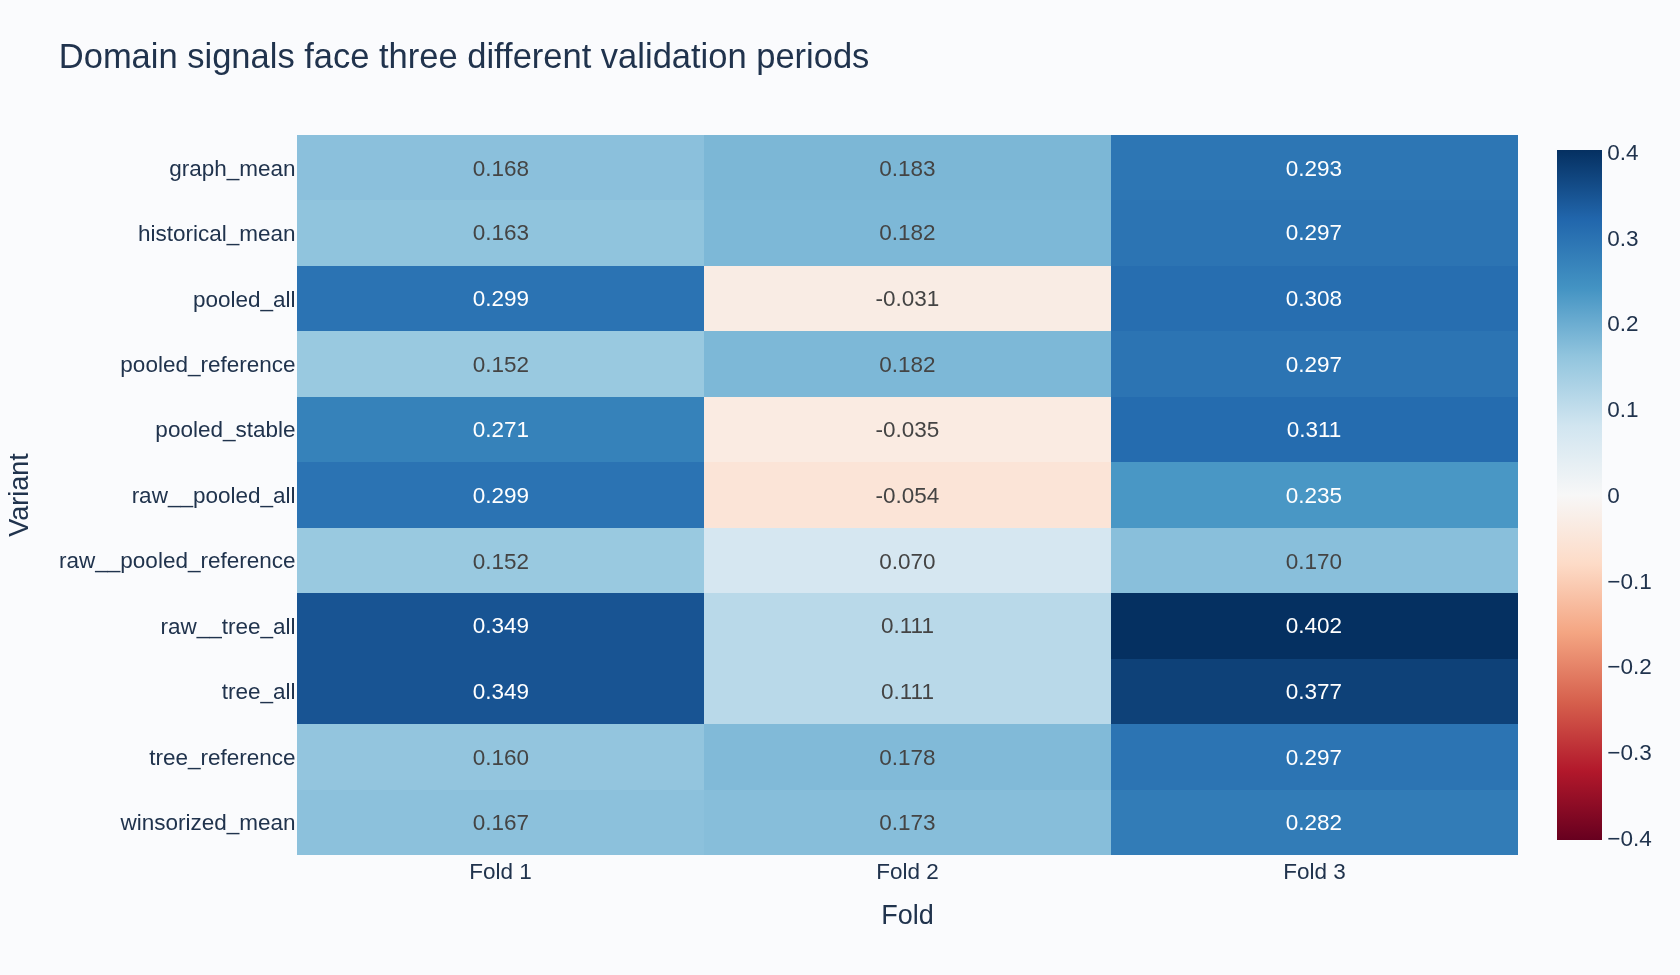

,Variant,Weights chosen inside training,Adjacent-fold template Jaccard
0,pooled_reference,"[1.0, 0.0, 0.0]","[1.0, 1.0]"
1,pooled_all,"[1.0, 0.5, 0.05]","[0.7297297297297297, 0.9104477611940298]"
2,pooled_stable,"[1.0, 0.5, 0.05]","[0.6, 0.7297297297297297]"
3,tree_all,"[1.0, 1.0, 0.5]","[0.7297297297297297, 0.9104477611940298]"


,Variant,Horizon,eligible_dates,excluded_dates,mean_daily_rank_correlation,official_metric
0,historical_mean,1,534,1,0.0444,0.1757
1,historical_mean,2,533,2,0.0506,0.1749
2,historical_mean,3,533,2,0.0576,0.2077
3,historical_mean,4,532,3,0.0369,0.1665
4,pooled_all,1,534,1,0.0347,0.1111
5,pooled_all,2,533,2,0.0482,0.1483
6,pooled_all,3,533,2,0.0571,0.1758
7,pooled_all,4,532,3,0.0549,0.1757
8,raw__pooled_all,1,534,1,0.0227,0.0697
9,raw__pooled_all,2,533,2,0.0307,0.0956


In [15]:
stability_rows = [{"Variant":name,"Fold":f"Fold {i+1}","Metric":metric} for name in focus_names for i,metric in enumerate(domain["summaries"][name]["fold_scores"])]
matrix = pd.DataFrame(stability_rows).pivot(index="Variant",columns="Fold",values="Metric")
fig = px.imshow(matrix,text_auto=".3f",color_continuous_scale="RdBu",color_continuous_midpoint=0,aspect="auto",title="Domain signals face three different validation periods")
show_figure(fig,root,"domain_fold_stability",650)
display(pd.DataFrame([{"Variant":name, "Weights chosen inside training":domain["summaries"][name]["residual_weights"], "Adjacent-fold template Jaccard":domain["summaries"][name]["adjacent_fold_selection_jaccard"]} for name in ["pooled_reference","pooled_all","pooled_stable","tree_all"]]))
display(pd.DataFrame([{"Variant":name,"Horizon":h,**m} for name in ["historical_mean","pooled_all","raw__pooled_all"] for h,m in domain["summaries"][name]["horizon_metrics"].items()]).round(4))

### Audit what the full model retained

These counts refer to a **single pooled model per fold**. They are not comparable with sums over 424 target-specific models in the earlier study. A rejected template may be constant, duplicated, highly correlated, sparse, or below the fixed feature budget; rejection does not prove an economic mechanism absent.

,fold,candidate_templates,retained_templates,rejected_templates,rejection_reasons
0,0,380,64,316,"{'constant': 1, 'correlated': 3, 'duplicate': ..."
1,1,380,64,316,"{'constant': 1, 'correlated': 3, 'duplicate': ..."
2,2,380,64,316,"{'correlated': 3, 'duplicate': 3, 'feature_bud..."


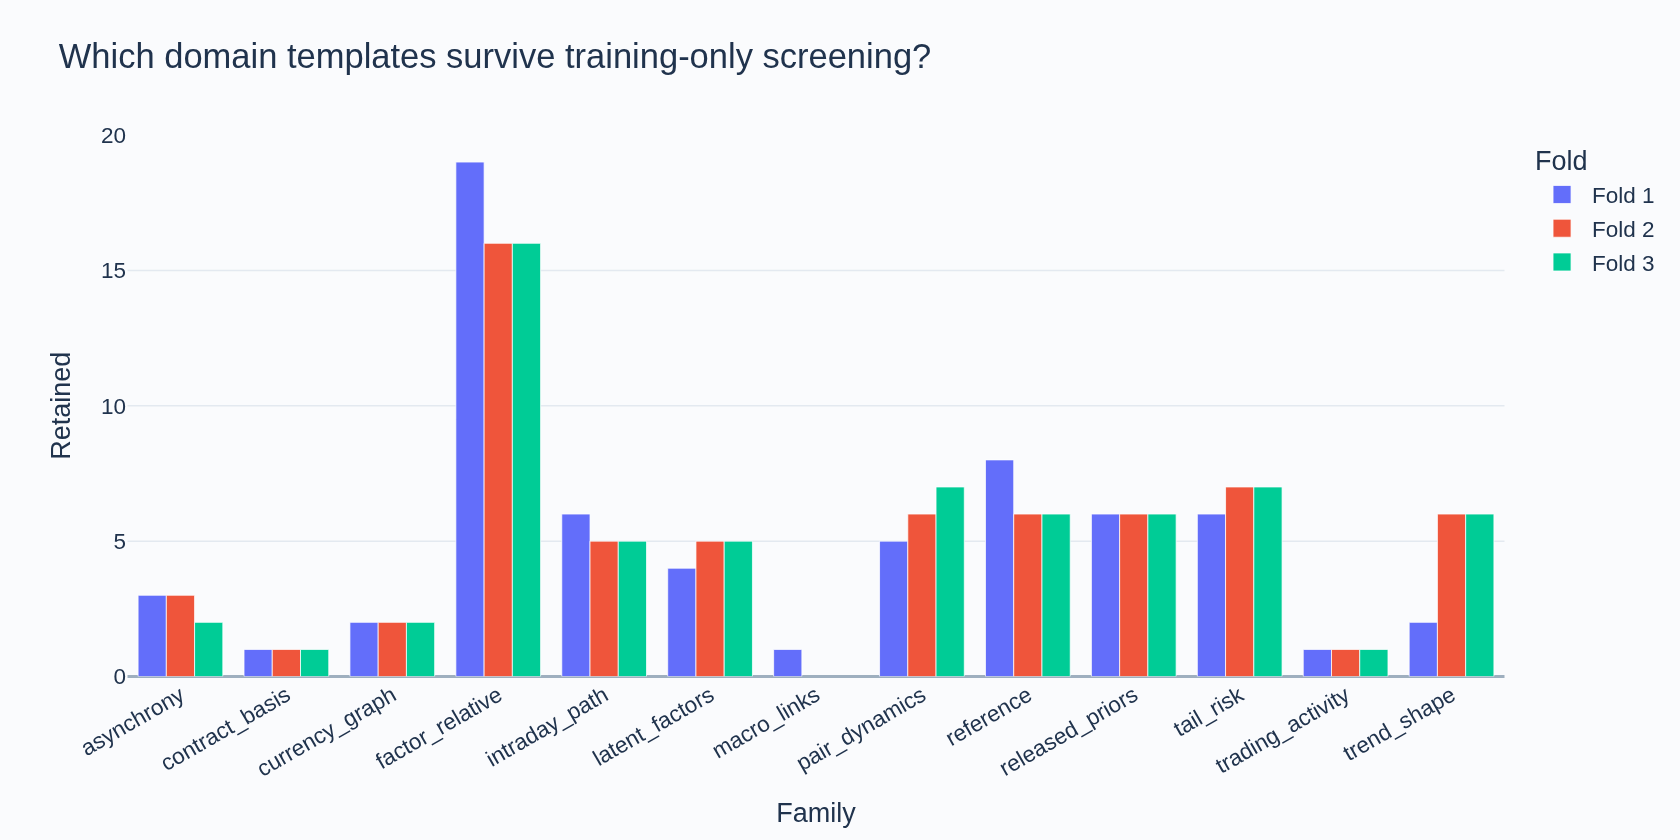

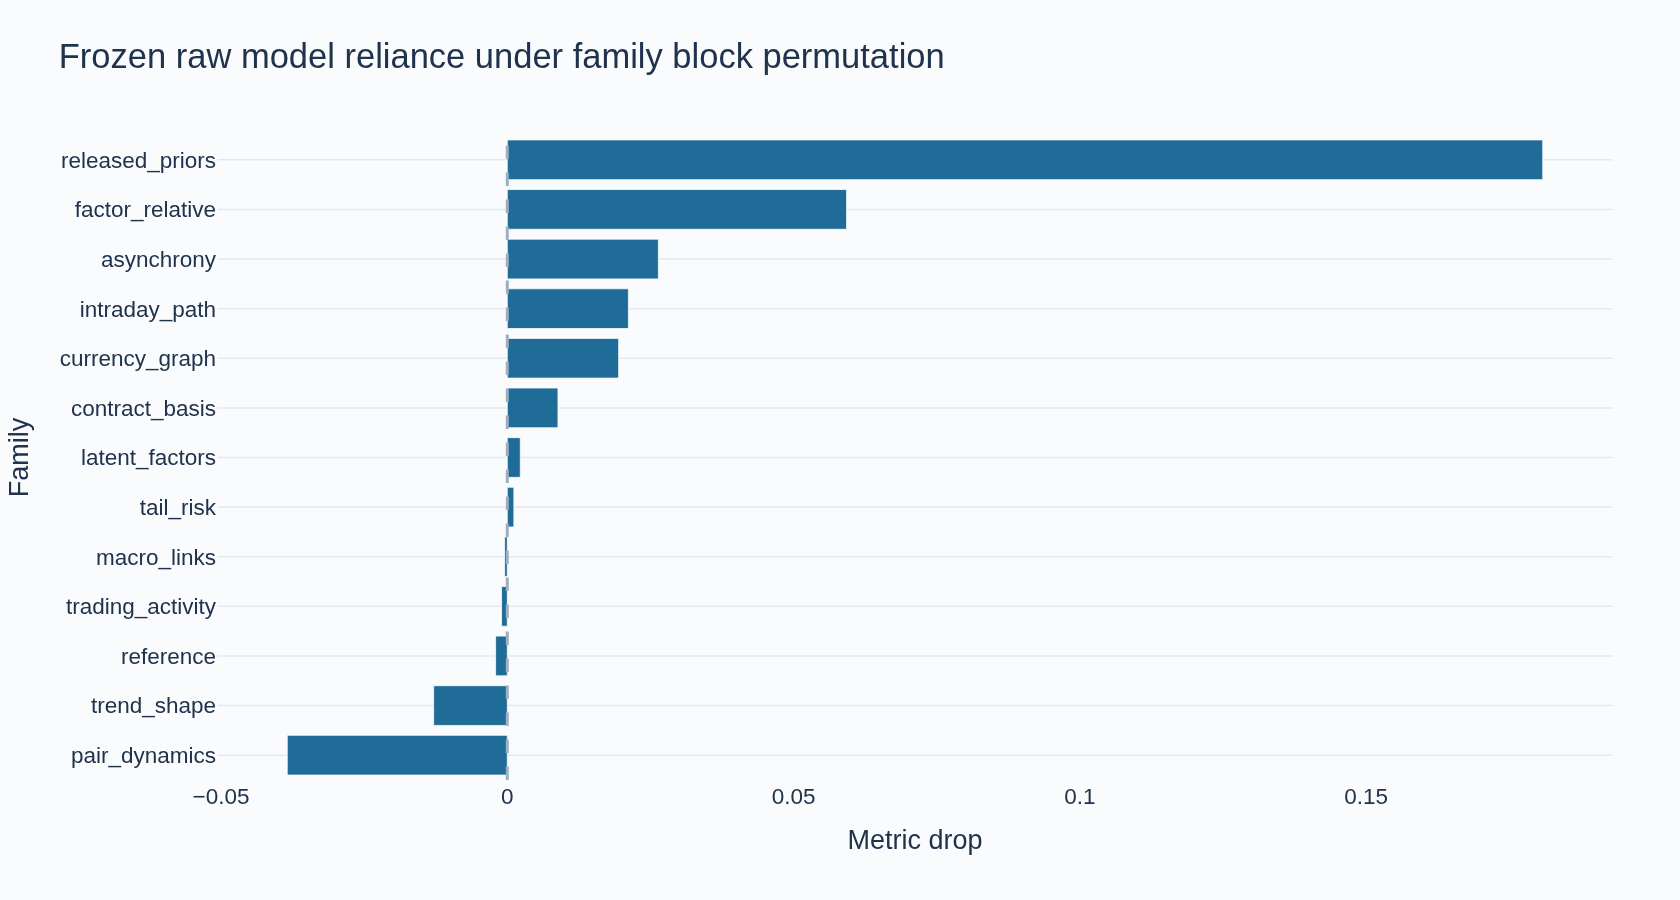

Permutation averages fold-level metric changes; it is neither a pooled score nor causal importance. Unselected families have no measured reliance in this particular frozen model.

In [16]:
display(pd.DataFrame([{k:r[k] for k in ["fold","candidate_templates","retained_templates","rejected_templates","rejection_reasons"]} for r in domain["screening"]]))
selected_rows = [{"Fold":f"Fold {r['fold']+1}","Family":family,"Retained":count} for r in domain["screening"] for family,count in r["retained_by_family"].items()]
fig = px.bar(pd.DataFrame(selected_rows),x="Family",y="Retained",color="Fold",barmode="group",title="Which domain templates survive training-only screening?")
fig.update_xaxes(tickangle=-30)
show_figure(fig,root,"domain_retained_families",560)
permuted = [{"Fold":r["fold"],"Family":family,"Metric drop":value} for r in domain["group_permutation"] for family,s in r["families"].items() for value in s["metric_drop_repetitions"]]
if permuted:
    importance = pd.DataFrame(permuted).groupby("Family")["Metric drop"].mean().sort_values().reset_index()
    fig = px.bar(importance,x="Metric drop",y="Family",orientation="h",title="Frozen raw model reliance under family block permutation")
    fig.update_traces(marker_color="#1F6C99")
    fig.add_vline(x=0,line_dash="dash",line_color="#9EAFBF")
    show_figure(fig,root,"domain_group_permutation",600)
display(Markdown("Permutation averages fold-level metric changes; it is neither a pooled score nor causal importance. Unselected families have no measured reliance in this particular frozen model."))

In [17]:
leader = domain_rows.sort_values("Metric",ascending=False).iloc[0]
mean_score = domain["summaries"]["historical_mean"]["official_metric"]
evidence20 = domain_bounds.loc[domain_bounds.block_dates == 20]
positive = evidence20.loc[evidence20.simultaneous_95_interval.map(lambda v:v[0]>0)]
matched_positive = positive.loc[(positive.variant.str.contains("add_")) | (positive.reference.str.contains("drop_")) | ((positive.reference.str.contains("reference")) & (positive.variant.str.contains("all")))]
display(Markdown(f"**Observed point-estimate leader:** `{leader.Variant}` at **{leader.Metric:.5f}**, versus historical means at **{mean_score:.5f}**. This ranking includes exploratory variants and is not a final-model selection.\n\n**{len(matched_positive)} matched feature comparisons** have positive simultaneous lower bounds at the 20-date block setting, among **{domain['declared_comparison_count']} declared comparisons**. Consult the 10/40-date sensitivity before interpreting them.\n\n**Completed:** {domain['new_fitted_models']} new fitted models, {domain['outer_evaluations']} outer evaluations, and preserved prior studies. Final test: **not evaluated**. Feature gate: **open**."))
display(domain_rows.sort_values("Metric",ascending=False).head(12).round(5))

**Observed point-estimate leader:** `raw__tree_all` at **0.27689**, versus historical means at **0.21774**. This ranking includes exploratory variants and is not a final-model selection.

**0 matched feature comparisons** have positive simultaneous lower bounds at the 20-date block setting, among **122 declared comparisons**. Consult the 10/40-date sensitivity before interpreting them.

**Completed:** 279 new fitted models, 102 outer evaluations, and preserved prior studies. Final test: **not evaluated**. Feature gate: **open**.

,Variant,Metric,Fold scores,Residual weights
60,raw__tree_all,0.27689,"[0.348696570690272, 0.11147004877633712, 0.402...","[1.0, 1.0, 1.0]"
62,tree_all,0.27061,"[0.348696570690272, 0.11147004877633712, 0.377...","[1.0, 1.0, 0.5]"
1,add_contract_basis,0.22906,"[0.20919028352797994, 0.17677157446519964, 0.2...","[1.0, 0.05, 0.0]"
2,add_currency_graph,0.22122,"[0.1777937577204256, 0.1824882692897385, 0.296...","[1.0, 0.0, 0.0]"
16,drop_factor_relative,0.22054,"[0.3980284008462009, -0.04015931872802721, 0.3...","[1.0, 0.5, 0.1]"
26,graph_mean,0.21856,"[0.1682421380744304, 0.18336490457535354, 0.29...","[0, 0, 0]"
12,add_trend_shape,0.21790,"[0.22369231519836671, 0.1259217807366325, 0.30...","[1.0, 0.25, 0.25]"
27,historical_mean,0.21774,"[0.1625498054219968, 0.1824882692897385, 0.296...","[0, 0, 0]"
8,add_pair_dynamics,0.21774,"[0.1625498054219968, 0.1824882692897385, 0.296...","[0.0, 0.0, 0.0]"
63,tree_reference,0.21556,"[0.1601678548389069, 0.17848568651184174, 0.29...","[1.0, 0.1, 0.0]"


### Research decision and remaining stones

This is evidence about the tested representations under fixed models, not a claim that every economic avenue is exhausted. Examine conditional target groups, nonlinear interactions, alternative normalization and robust priors only where the measured weaknesses justify them. Preserve failed hypotheses and matched comparisons; do not promote a family because of its name or column count.

True futures carry needs dated delivery curves; inventories and positioning need publication vintages; seasonality and weather need a verified calendar; fundamentals need historical classifications; options and news need appropriately licensed as-of records. These prerequisites are explicit in the [domain ledger](../docs/domain-feature-research.md). Feature engineering remains open until major feasible avenues, stability, and diminishing returns have sufficient evidence. **No final optimization, final-test evaluation, or competition submissions were performed.**

## Follow the nonlinear signal with matched family attribution

The parent tree improved its point estimate, while uncertainty remained wide. This explicitly exploratory follow-up tests **13 additions and 13 removals with the fixed tree** across the same three folds. All 78 fits reuse the existing feature panel; the reference, full, and historical-mean controls are preserved. Residual weight stays at one to assess unshrunk feature contributions. No hyperparameter search or additional validation dates are introduced.

The bounds now cover **177 comparisons jointly across both domain phases**. They still cannot turn adaptive development research into independent confirmation.

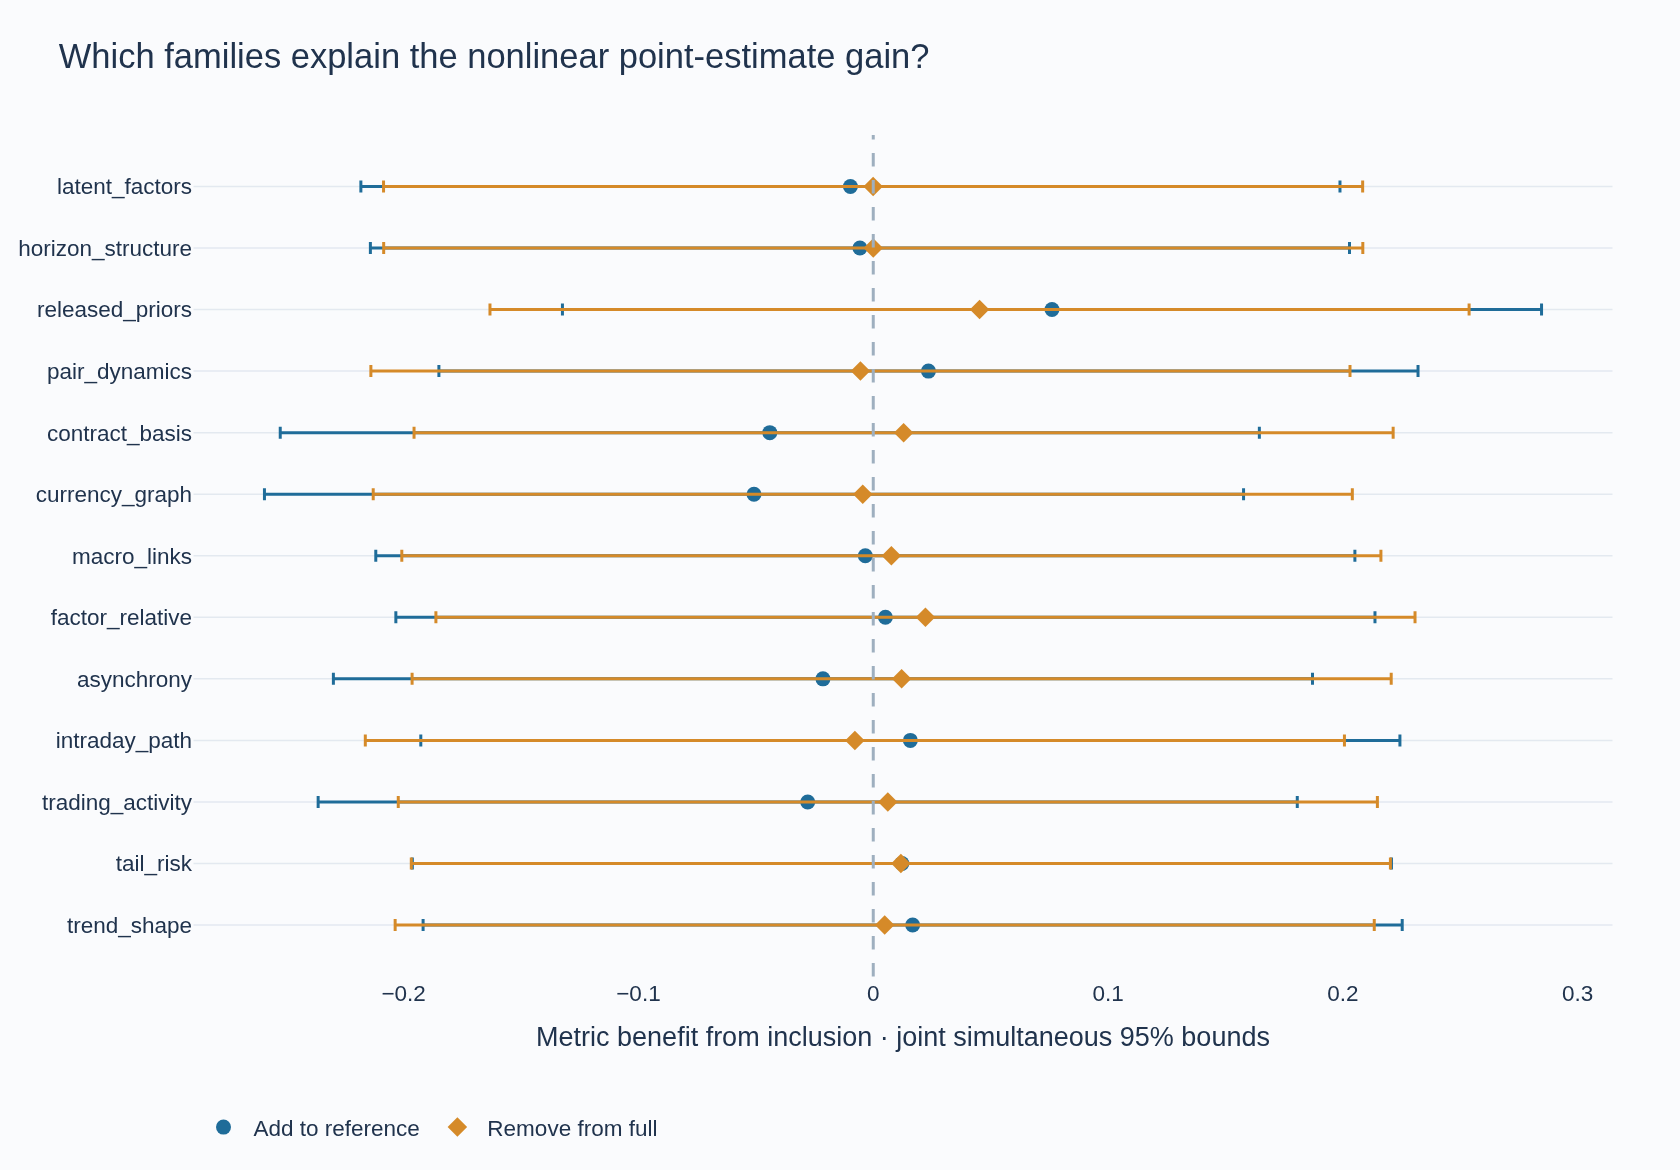

,Variant,Metric,Fold scores
19,drop_intraday_path,0.28471,"[0.2980378054192665, 0.14050663773921027, 0.43..."
22,drop_pair_dynamics,0.28234,"[0.3562596450879688, 0.11913444763471884, 0.40..."
16,drop_currency_graph,0.28135,"[0.3617542566610662, 0.13133057007714677, 0.38..."
9,add_released_priors,0.28124,"[0.33756551282189656, 0.15844732224303942, 0.3..."
20,drop_latent_factors,0.27695,"[0.35144383187907025, 0.11716350214200981, 0.3..."
13,all_control,0.27689,"[0.348696570690272, 0.11147004877633712, 0.402..."
18,drop_horizon_structure,0.27689,"[0.348696570690272, 0.11147004877633712, 0.402..."
26,drop_trend_shape,0.27201,"[0.329379299844656, 0.11388415063234837, 0.399..."
25,drop_trading_activity,0.27068,"[0.35300035480162745, 0.09930787196664206, 0.3..."
21,drop_macro_links,0.26917,"[0.31874534790793174, 0.11147004877633712, 0.4..."


In [18]:
tree_rows = pd.DataFrame([{"Variant":name,"Metric":m["official_metric"],"Fold scores":m["fold_scores"]} for name,m in attribution["summaries"].items()])
matched_tree = []
for r in attribution["comparisons"]:
    if r["block_dates"] != 20:
        continue
    if r["variant"].startswith("add_") and r["reference"] == "reference_control":
        matched_tree.append({**r,"Family":r["variant"].removeprefix("add_"),"Test":"Add to reference"})
    elif r["variant"] == "all_control" and r["reference"].startswith("drop_"):
        matched_tree.append({**r,"Family":r["reference"].removeprefix("drop_"),"Test":"Remove from full"})
matched_tree = pd.DataFrame(matched_tree)
fig = go.Figure()
for label,color,symbol in [("Add to reference","#1F6C99","circle"),("Remove from full","#D58A29","diamond")]:
    group = matched_tree.loc[matched_tree.Test == label]
    lo=group.simultaneous_95_interval.map(lambda v:v[0]); hi=group.simultaneous_95_interval.map(lambda v:v[1])
    fig.add_trace(go.Scatter(x=group.delta,y=group.Family,mode="markers",name=label,marker={"color":color,"symbol":symbol,"size":10},error_x={"type":"data","symmetric":False,"array":hi-group.delta,"arrayminus":group.delta-lo}))
fig.add_vline(x=0,line_dash="dash",line_color="#9EAFBF")
fig.update_layout(title="Which families explain the nonlinear point-estimate gain?",xaxis_title="Metric benefit from inclusion · joint simultaneous 95% bounds",legend={"orientation":"h","y":-0.15})
show_figure(fig,root,"tree_matched_families",780)
display(tree_rows.sort_values("Metric",ascending=False).head(15).round(5))

### Test reliance in the model that showed the gain

The original domain permutation diagnosed the pooled linear model. This follow-up perturbs each selected family in the **saved full tree** using shared date blocks across targets, without refitting. Addition, removal, and permutation address different questions; agreement across them is more useful than a single importance ranking.

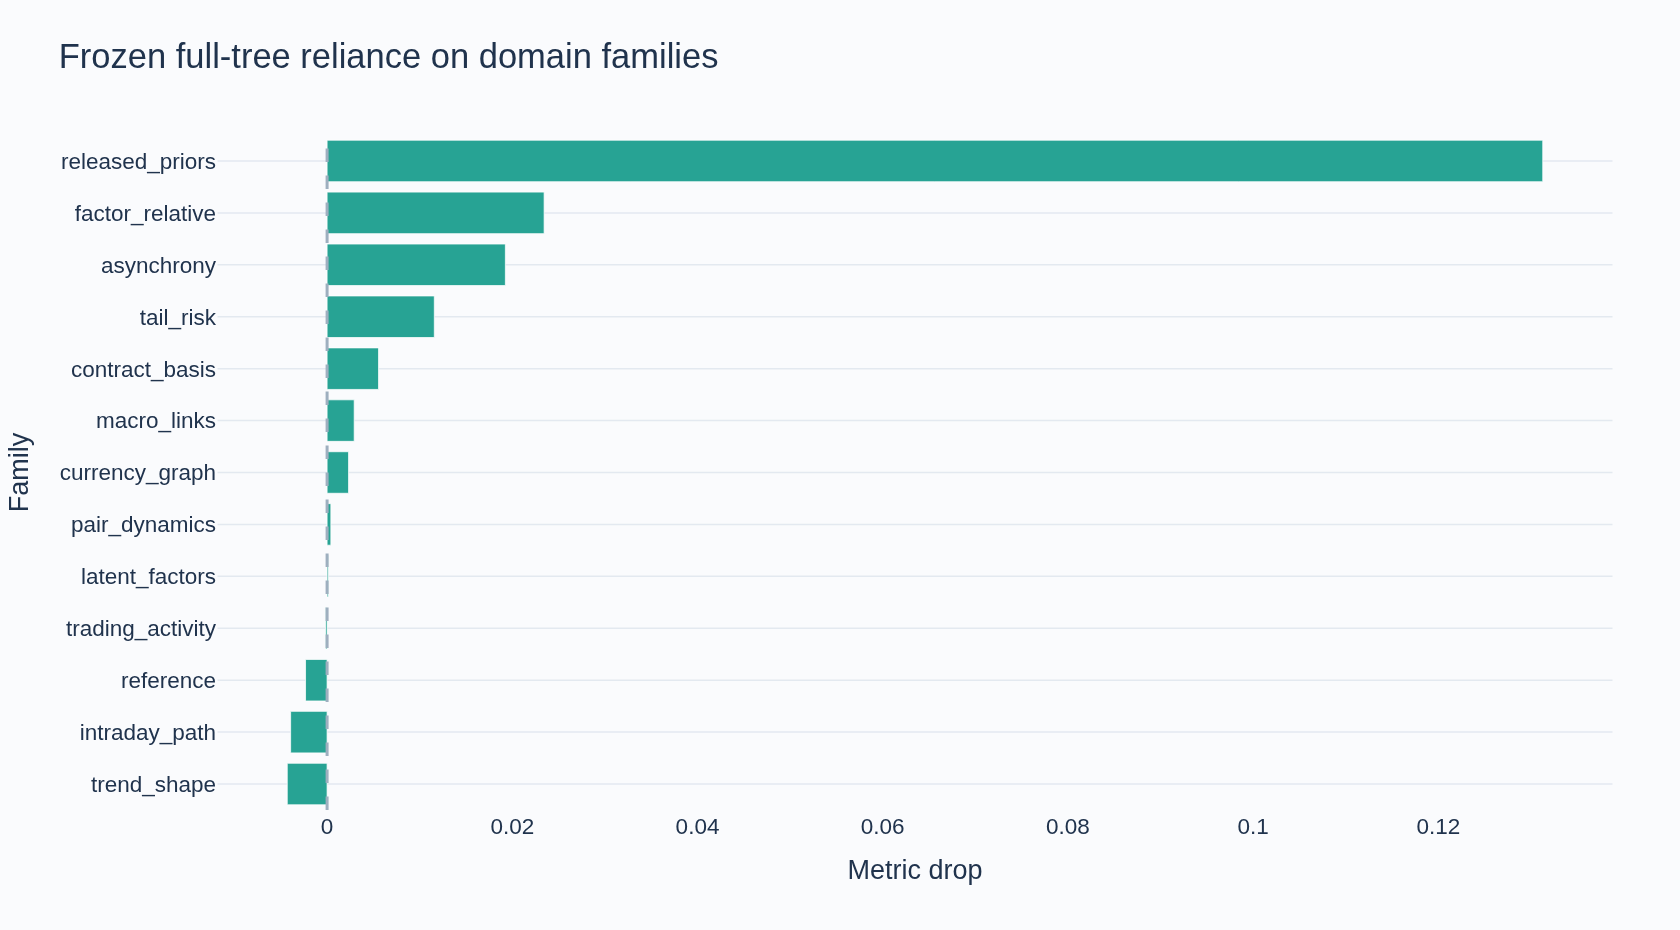

,Family,Test,delta,conditional_95_interval,simultaneous_95_interval
10,released_priors,Add to reference,0.076126,"[-0.020015243777972522, 0.17453426890873908]","[-0.1323729942052409, 0.2846243743494701]"
9,pair_dynamics,Add to reference,0.023515,"[-0.011115058714952443, 0.05731617708113695]","[-0.1849833318414198, 0.23201403671329118]"
0,trend_shape,Add to reference,0.016785,"[-0.034864709692172514, 0.06955572766102647]","[-0.1917138487491528, 0.2252835198055582]"
3,intraday_path,Add to reference,0.015805,"[-0.04578207168754259, 0.07845761782503216]","[-0.1926939399540505, 0.22430342860066046]"
1,tail_risk,Add to reference,0.012206,"[-0.05483239741473358, 0.08103377707751555]","[-0.19629262589595609, 0.2207047426587549]"
5,factor_relative,Add to reference,0.005182,"[-0.05589435061841184, 0.06614061296210554]","[-0.2033168528289308, 0.21368051572578017]"
6,macro_links,Add to reference,-0.003372,"[-0.0753567190854019, 0.06990585205114822]","[-0.21187023307882574, 0.20512713547588524]"
11,horizon_structure,Add to reference,-0.005668,"[-0.02501301935691094, 0.011922558432525685]","[-0.21416626706802586, 0.20283110148668512]"
12,latent_factors,Add to reference,-0.009722,"[-0.11501014652490064, 0.0897360271133266]","[-0.21822020409279042, 0.19877716446192056]"
4,asynchrony,Add to reference,-0.021423,"[-0.08307736117684414, 0.03914961903322346]","[-0.2299218312023447, 0.1870755373523663]"


In [19]:
tree_permuted = [{"Family":family,"Metric drop":v} for record in attribution["group_permutation"] for family,m in record["families"].items() for v in m["metric_drop_repetitions"]]
importance = pd.DataFrame(tree_permuted).groupby("Family")["Metric drop"].mean().sort_values().reset_index()
fig = px.bar(importance,x="Metric drop",y="Family",orientation="h",title="Frozen full-tree reliance on domain families")
fig.update_traces(marker_color="#27A394")
fig.add_vline(x=0,line_dash="dash",line_color="#9EAFBF")
show_figure(fig,root,"tree_group_permutation",620)
display(matched_tree[["Family","Test","delta","conditional_95_interval","simultaneous_95_interval"]].sort_values(["Test","delta"],ascending=[True,False]))

In [20]:
tree_best = tree_rows.sort_values("Metric",ascending=False).iloc[0]
positive_tree = matched_tree.loc[matched_tree.simultaneous_95_interval.map(lambda v:v[0]>0)]
joint_positive = [r for r in attribution["joint_comparisons"] if r["block_dates"]==20 and r["simultaneous_95_interval"][0]>0]
display(Markdown(f"**Tree attribution point-estimate leader:** `{tree_best.Variant}` at **{tree_best.Metric:.5f}**. **{len(positive_tree)} of 26 matched tree-family comparisons** have positive simultaneous lower bounds at the 20-date setting. Across both domain phases, **{len(joint_positive)} of {attribution['joint_comparison_count']} comparisons** have positive lower bounds.\n\nThe study completed **{domain['new_fitted_models'] + attribution['new_fitted_models']} new fitted models** across both domain phases, plus nine mean-control evaluations. All earlier 99 fold experiments are preserved. Feature engineering remains **open**; final evaluation has not run."))

**Tree attribution point-estimate leader:** `drop_intraday_path` at **0.28471**. **0 of 26 matched tree-family comparisons** have positive simultaneous lower bounds at the 20-date setting. Across both domain phases, **0 of 177 comparisons** have positive lower bounds.

The study completed **357 new fitted models** across both domain phases, plus nine mean-control evaluations. All earlier 99 fold experiments are preserved. Feature engineering remains **open**; final evaluation has not run.

### Decision after the matched nonlinear tests

Use this evidence to identify conditional mechanisms worth further scrutiny, not to pick a winner from a leaderboard of development scores. A positive pooled estimate needs adequate uncertainty bounds, consistent temporal behavior, and robustness to alternative representations before promotion. No family is established merely by a high point estimate or a low permutation score.

Remaining research includes defensible conditional interactions and target-group behavior, plus data-dependent carry, physical supply, positioning, calendar, option, and event features. The domain ledger states the prerequisites for each. The final test and final optimization remain gated. [Complete tree evidence](../reports/tree_attribution.json) · [Domain ledger](../docs/domain-feature-research.md).

## Feature robustness: screening, timing, and conditional mechanisms

The preceding experiments leave specific alternatives unresolved. A 64-template relevance screen may hide complementary nonlinear information. Released priors may depend on very recent outcomes. Pooling can hide differences between horizons and markets. This exploratory follow-up tests those possibilities with **36 additional fits**, holding the unshrunk histogram-tree settings and the 535-date evaluation fixed. It reuses all parent controls and preserves their lineages.

There are **56 prior-by-group interactions** (14 released-prior summaries × four explicit metadata gates) and **12 bounded return/trend-by-shock/activity/freshness products**. These add 68 distinct templates to the research inventory, not 68 independent information sources. Market gates use the fraction of target legs in the market; the horizon gate identifies horizons 3 and 4. Structural absence is zero, applicable missingness remains missing.

The extra 1/5-date prior delays occur after the original horizon+1 release delay. The one-date market delay leaves static target metadata and already released priors unchanged. Increasing or removing the selection budget does not increase the tree's depth or iterations.

**Verified follow-up:** `d3fb7b5fbbaae6f4` · 36 fits · 37 sealed stages · replay error 0.0e+00

,Metric,Fold 1,Fold 2,Fold 3
Variant,,,,
all_control,0.276887,0.348697,0.111470,0.402333
budget_128,0.253915,0.276905,0.109191,0.393259
budget_32,0.256377,0.279737,0.122957,0.377635
budget_all,0.240974,0.242022,0.153677,0.328537
compact_conditional,0.206819,0.195020,0.105905,0.331924
compact_control,0.281237,0.337566,0.158447,0.352253
compact_factor,0.258062,0.228572,0.177229,0.360816
compact_risk_freshness,0.297055,0.379097,0.161987,0.377367
conditional_priors,0.228681,0.232448,0.086542,0.390818


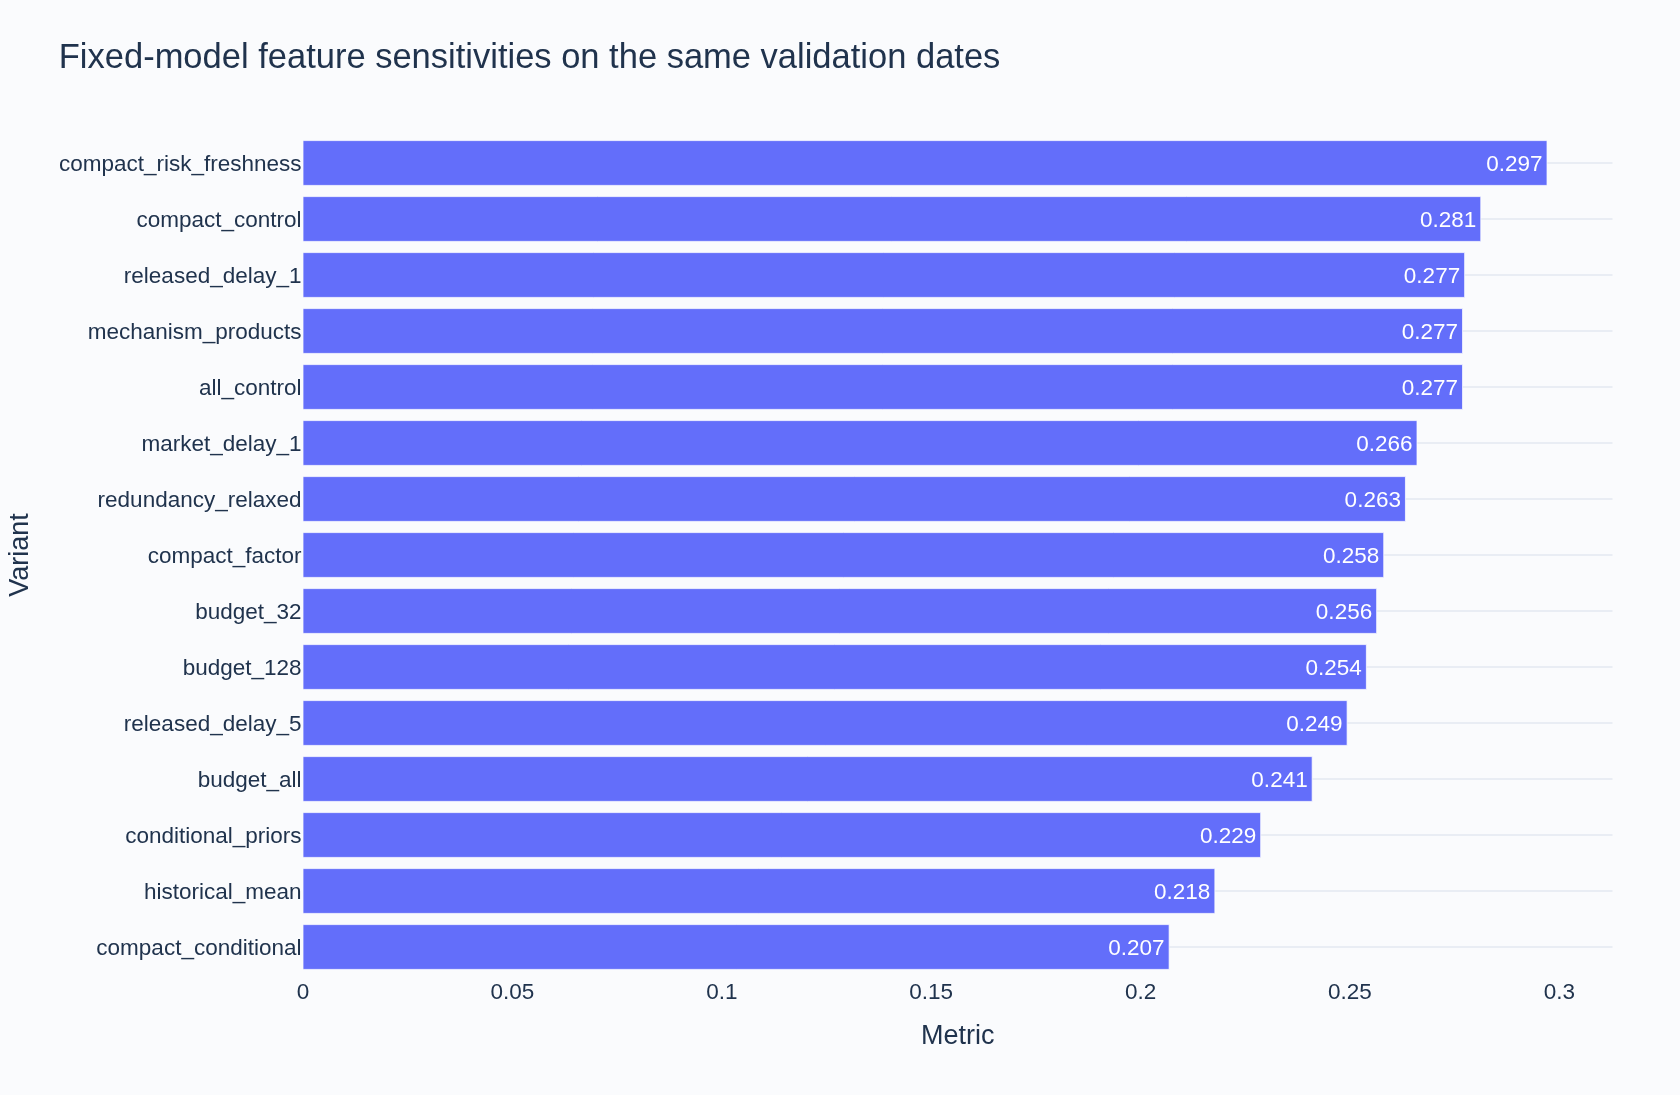

In [21]:
from scripts.notebook_support import checked_robustness
robustness = checked_robustness(root)
display(Markdown(f"**Verified follow-up:** `{robustness['lineage'][:16]}` · {robustness['new_fitted_models']} fits · {robustness['checkpoint_count']} sealed stages · replay error {robustness['maximum_prediction_replay_error']:.1e}"))
rows = [{"Variant":n,"Metric":s["official_metric"],"Fold 1":s["fold_scores"][0],"Fold 2":s["fold_scores"][1],"Fold 3":s["fold_scores"][2]} for n,s in robustness["summaries"].items()]
display(pd.DataFrame(rows).set_index("Variant").round(6))
fig = px.bar(pd.DataFrame(rows).sort_values("Metric"),x="Metric",y="Variant",orientation="h",text_auto=".3f",title="Fixed-model feature sensitivities on the same validation dates")
fig.update_layout(margin={"l":220})
show_figure(fig,root,"robustness_scores",730)

### Matched effects and representation size

Comparisons against the frozen full tree isolate the changed feature representation. Compact conditional, factor, and risk/freshness representations also compare with the frozen reference-plus-priors tree. The simultaneous interval family expands to include all declared comparisons from the three domain phases. These exploratory intervals condition on fitted models; they cannot restore independence after repeated development research. An interval crossing zero is inconclusive, rather than proof of equivalence.

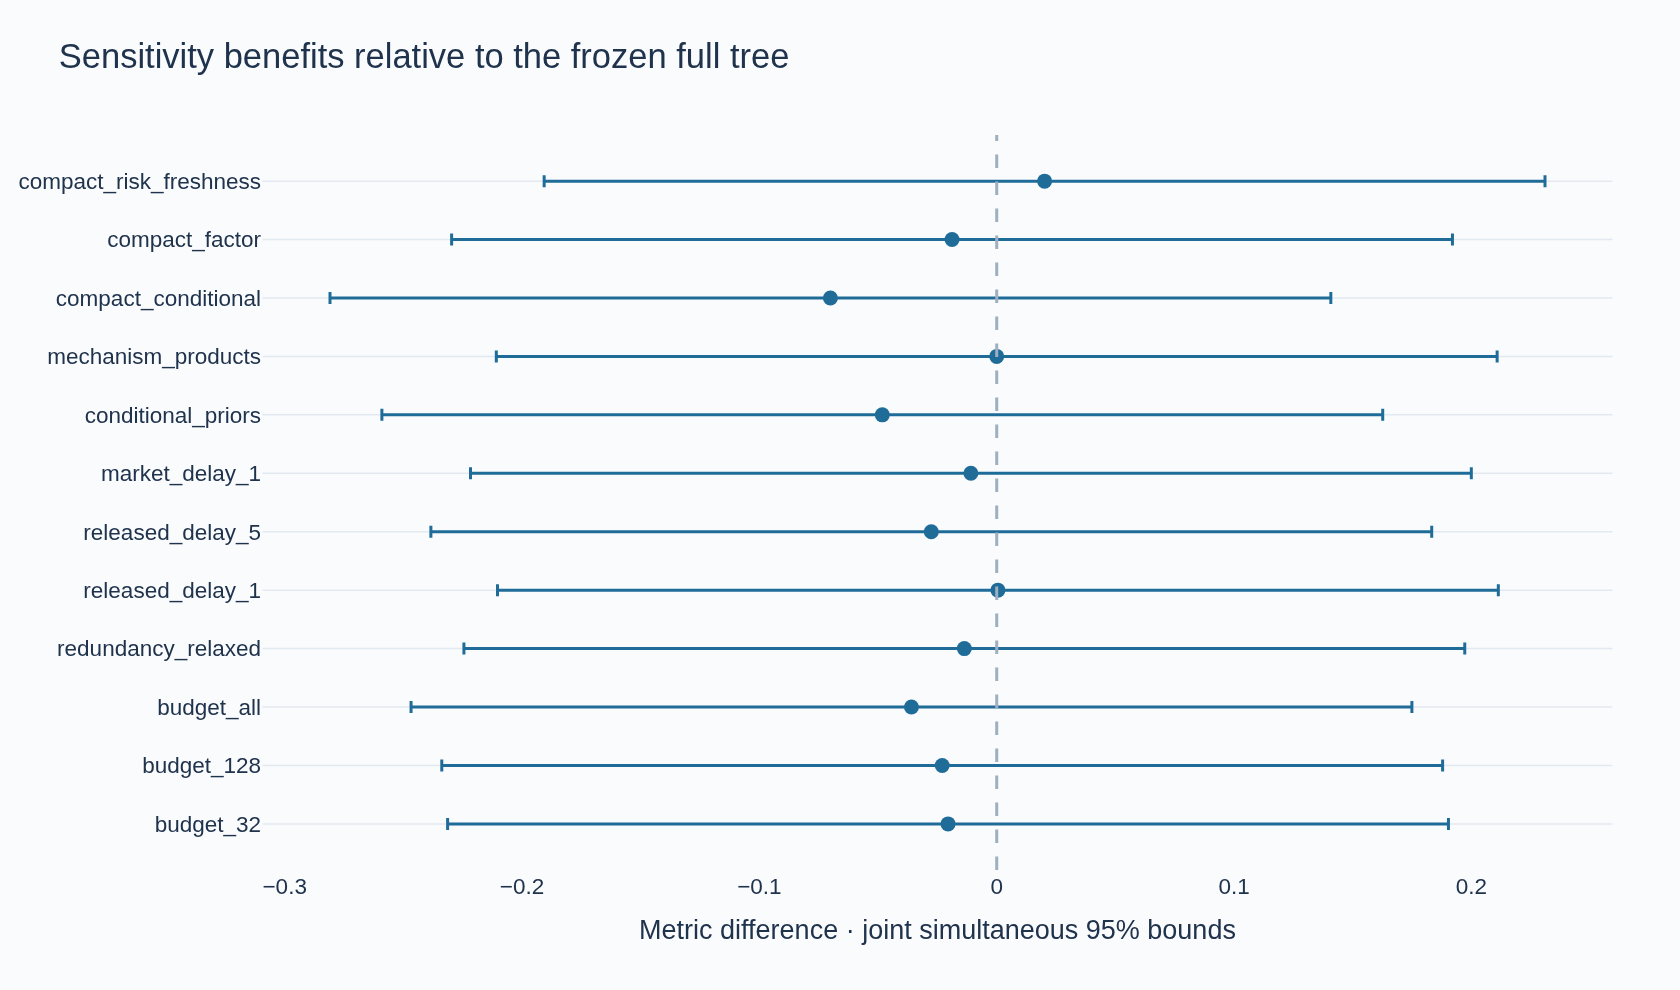

,Variant,Fold,Candidates,Retained,Rejected,Reasons
0,budget_32,1,380,32,348,"{'constant': 1, 'correlated': 3, 'duplicate': ..."
1,budget_128,1,380,128,252,"{'constant': 1, 'correlated': 5, 'duplicate': ..."
2,budget_all,1,380,363,17,"{'constant': 1, 'correlated': 13, 'duplicate': 3}"
3,redundancy_relaxed,1,380,376,4,"{'constant': 1, 'duplicate': 3}"
4,released_delay_1,1,380,64,316,"{'constant': 1, 'correlated': 3, 'duplicate': ..."
5,released_delay_5,1,380,64,316,"{'constant': 1, 'correlated': 3, 'duplicate': ..."
6,market_delay_1,1,380,64,316,"{'constant': 1, 'correlated': 5, 'duplicate': ..."
7,conditional_priors,1,436,64,372,"{'constant': 1, 'correlated': 10, 'duplicate':..."
8,mechanism_products,1,392,64,328,"{'constant': 3, 'correlated': 3, 'duplicate': ..."
9,compact_conditional,1,95,64,31,"{'correlated': 12, 'feature_budget': 19}"


Joint comparison count: **204**. Positive simultaneous lower bounds by block length: **{10: 0, 20: 0, 40: 0}**. Feature gate remains **open**.

In [22]:
matched = pd.DataFrame([r for r in robustness["comparisons"] if r["block_dates"] == 20 and r["reference"] == "all_control"])
fig = go.Figure()
fig.add_trace(go.Scatter(x=matched.delta,y=matched.variant,mode="markers",marker={"size":10,"color":"#1F6C99"},error_x={"type":"data","symmetric":False,"array":[r[1]-d for r,d in zip(matched.simultaneous_95_interval,matched.delta)],"arrayminus":[d-r[0] for r,d in zip(matched.simultaneous_95_interval,matched.delta)]}))
fig.add_vline(x=0,line_dash="dash",line_color="#9EAFBF")
fig.update_layout(title="Sensitivity benefits relative to the frozen full tree",xaxis_title="Metric difference · joint simultaneous 95% bounds",margin={"l":220})
show_figure(fig,root,"robustness_uncertainty",660)
screen = pd.DataFrame([{"Variant":r["variant"],"Fold":r["fold"]+1,"Candidates":r["selection"]["candidate_templates"],"Retained":r["selection"]["retained_templates"],"Rejected":r["selection"]["rejected_templates"],"Reasons":r["selection"]["rejection_reasons"]} for r in robustness["results"]])
display(screen)
counts = {b:sum(r["simultaneous_95_interval"][0]>0 for r in robustness["joint_comparisons"] if r["block_dates"]==b) for b in [10,20,40]}
display(Markdown(f"Joint comparison count: **{robustness['joint_comparison_count']}**. Positive simultaneous lower bounds by block length: **{counts}**. Feature gate remains **open**."))

### Subgroup diagnostics and unresolved mechanisms

Market-involved target groups overlap. Single/pair and within-market rankings change which targets are compared, so these descriptive scores are not substitutes for the global metric and are not independently significant findings. Compare a variant with its control within the same subgroup. Dates with fewer than two observed subgroup targets are excluded by a truth-only rule, and coverage is reported. Undefined subgroup scores remain null. The single-asset group has one target per horizon, so its individual horizon ranking scores are undefined. The global metric continues to use all 535 dates.

True delivery-curve carry, physical inventories, positioning, macro surprises, filings, options, and text still require verified dated inputs. Current website access does not establish historical data availability. The [domain research ledger](../docs/domain-feature-research.md) records source-specific timing, applicability, and the remaining evidence needed before feature-gate closure.

,Targets,Eligible dates,Excluded dates,Undefined
Group,,,,
FX_involved,134,535,0,None
JPX_involved,145,507,28,None
LME_involved,287,521,14,None
US_involved,270,517,18,None
paired,420,535,0,None
single,4,535,0,None


Group,FX_involved,JPX_involved,LME_involved,US_involved,paired,single
Variant,,,,,,
all_control,0.2742,0.2705,0.1963,0.1834,0.2748,0.1103
budget_128,0.2490,0.2636,0.1842,0.1731,0.2527,0.1026
budget_32,0.2476,0.2359,0.1890,0.1767,0.2545,0.1075
budget_all,0.2196,0.2721,0.1550,0.1662,0.2393,0.1027
compact_conditional,0.1687,0.2719,0.1058,0.1359,0.2067,0.0598
compact_control,0.1999,0.2886,0.1899,0.2078,0.2800,0.0989
compact_factor,0.2032,0.2614,0.1639,0.1877,0.2566,0.0919
compact_risk_freshness,0.2511,0.3094,0.2087,0.2087,0.2955,0.1211
conditional_priors,0.2446,0.2604,0.1487,0.1364,0.2274,0.1034


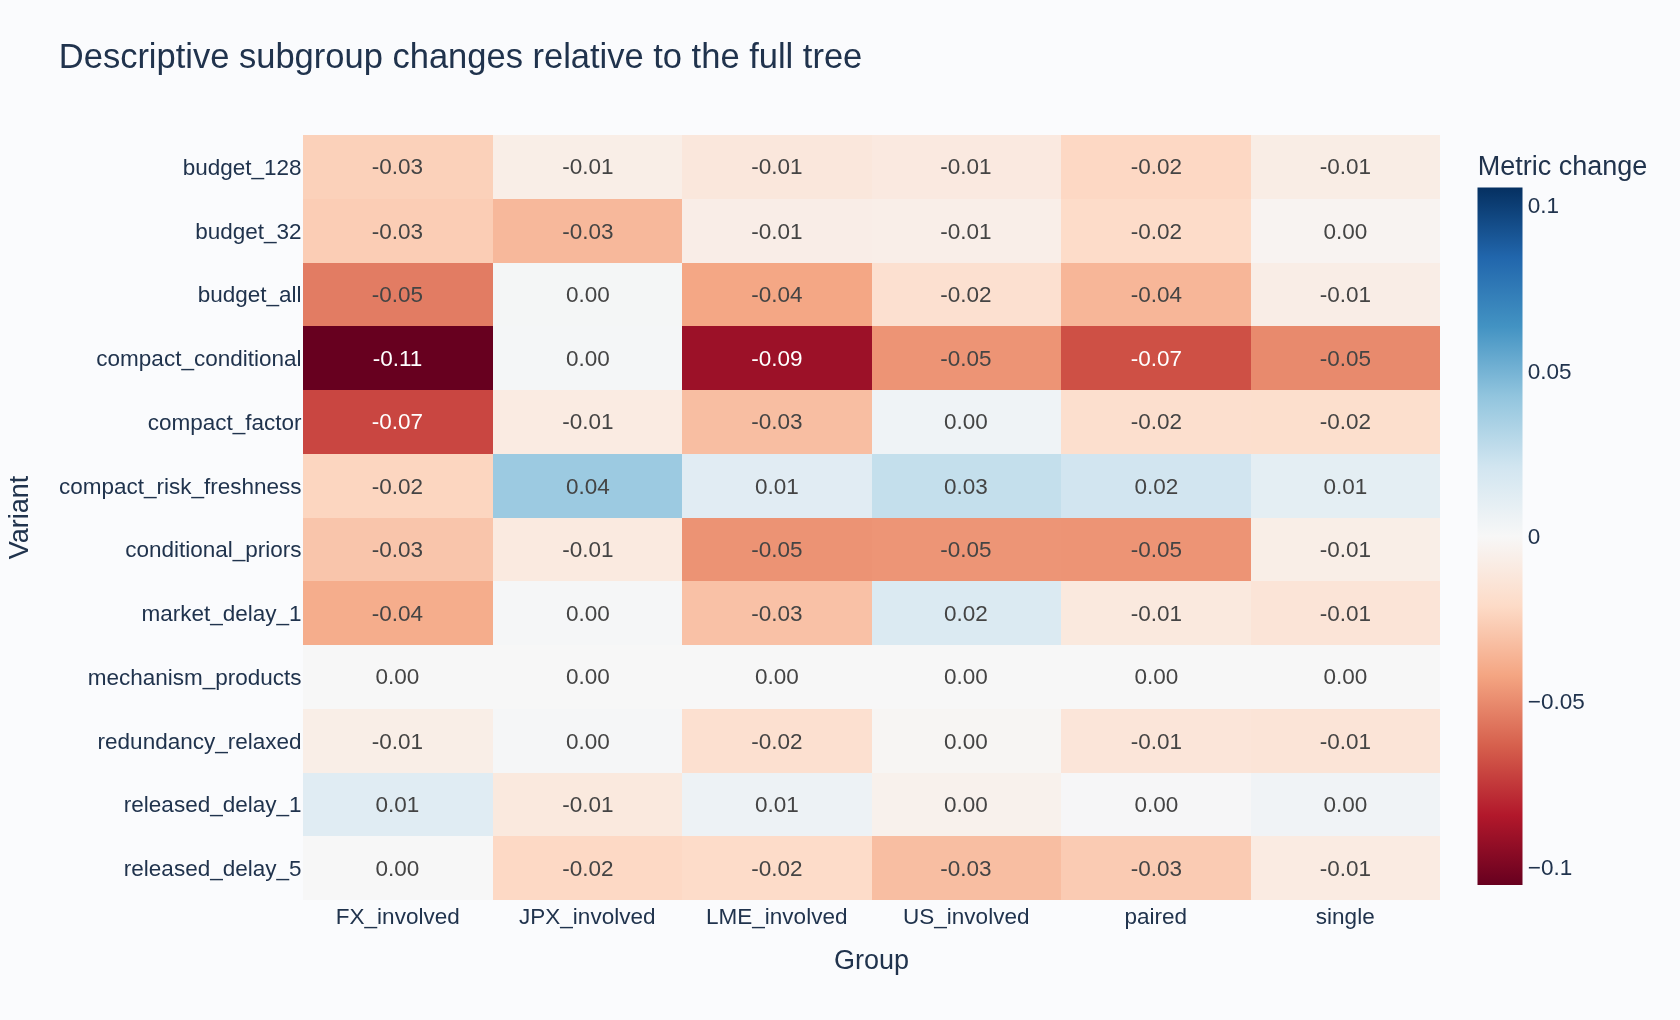

**Decision:** retain the complete evidence, including weak or negative hypotheses. Do not promote an exploratory point-estimate winner or touch the final test. A feature is not established by its name, count, or a single favorable fold.

In [23]:
groups = []
for n,s in robustness["summaries"].items():
    for group,g in s["subgroups"].items():
        groups.append({"Variant":n,"Group":group,"Targets":g["targets"],"Eligible dates":g["eligible_dates"],"Excluded dates":g["excluded_dates"],"Undefined":g["undefined_reason"],"Metric":g["official_metric"]})
display(pd.DataFrame(groups).query("Variant == 'all_control'")[["Group","Targets","Eligible dates","Excluded dates","Undefined"]].set_index("Group"))
group_table = pd.DataFrame(groups).pivot(index="Variant",columns="Group",values="Metric")
display(group_table.round(4))
control_groups = group_table.loc["all_control"]
delta_groups = group_table.drop(index=["all_control","historical_mean","compact_control"]).sub(control_groups,axis=1)
fig = px.imshow(delta_groups,color_continuous_scale="RdBu",color_continuous_midpoint=0,text_auto=".2f",aspect="auto",title="Descriptive subgroup changes relative to the full tree",labels={"color":"Metric change"})
show_figure(fig,root,"robustness_subgroups",680)
display(Markdown("**Decision:** retain the complete evidence, including weak or negative hypotheses. Do not promote an exploratory point-estimate winner or touch the final test. A feature is not established by its name, count, or a single favorable fold."))

## Compact feature mechanisms: separating evidence from screening

The preceding compact risk/freshness lead raises three different questions: which block helps, does it survive information delays, and did supervised screening hide interactions? This follow-up completes **36 fixed-tree fits** over the same three folds. It tests the reference-plus-priors base, the 30 tail-risk templates, the 12 freshness templates, and their joint representation. Both the original 64-column screen and a matched admission policy are reported.

**Admission policy:** keep every training-usable nonduplicate column. Missingness and constant checks remain; relevance ranking and near-correlation exclusions cannot remove a usable candidate. This tests the representation under the same 64-iteration tree capacity. It does not guarantee the model will learn every nonlinear relationship. The 12 previously screened-out products are reused exactly. A further 42 state-by-FX-leg-share templates test whether target representations need market-specific conditioning. They are not isolated FX-leg returns or new external information.

**Verified compact study:** `d8f4fe3423e890ee` · 36 fits · 37 sealed stages · exact replay error 0.0e+00

,Metric,Fold 1,Fold 2,Fold 3
Variant,,,,
admitted_base,0.280513,0.337542,0.154580,0.352277
admitted_freshness,0.281830,0.317206,0.190001,0.338418
admitted_fx_states,0.293456,0.339210,0.173975,0.384791
admitted_joint,0.303001,0.363156,0.164274,0.400578
admitted_products,0.302211,0.355181,0.166655,0.404485
admitted_tail,0.305336,0.390579,0.152341,0.399881
all_control,0.276887,0.348697,0.111470,0.402333
compact_both_delay_1,0.308814,0.336684,0.148136,0.467707
compact_control,0.281237,0.337566,0.158447,0.352253


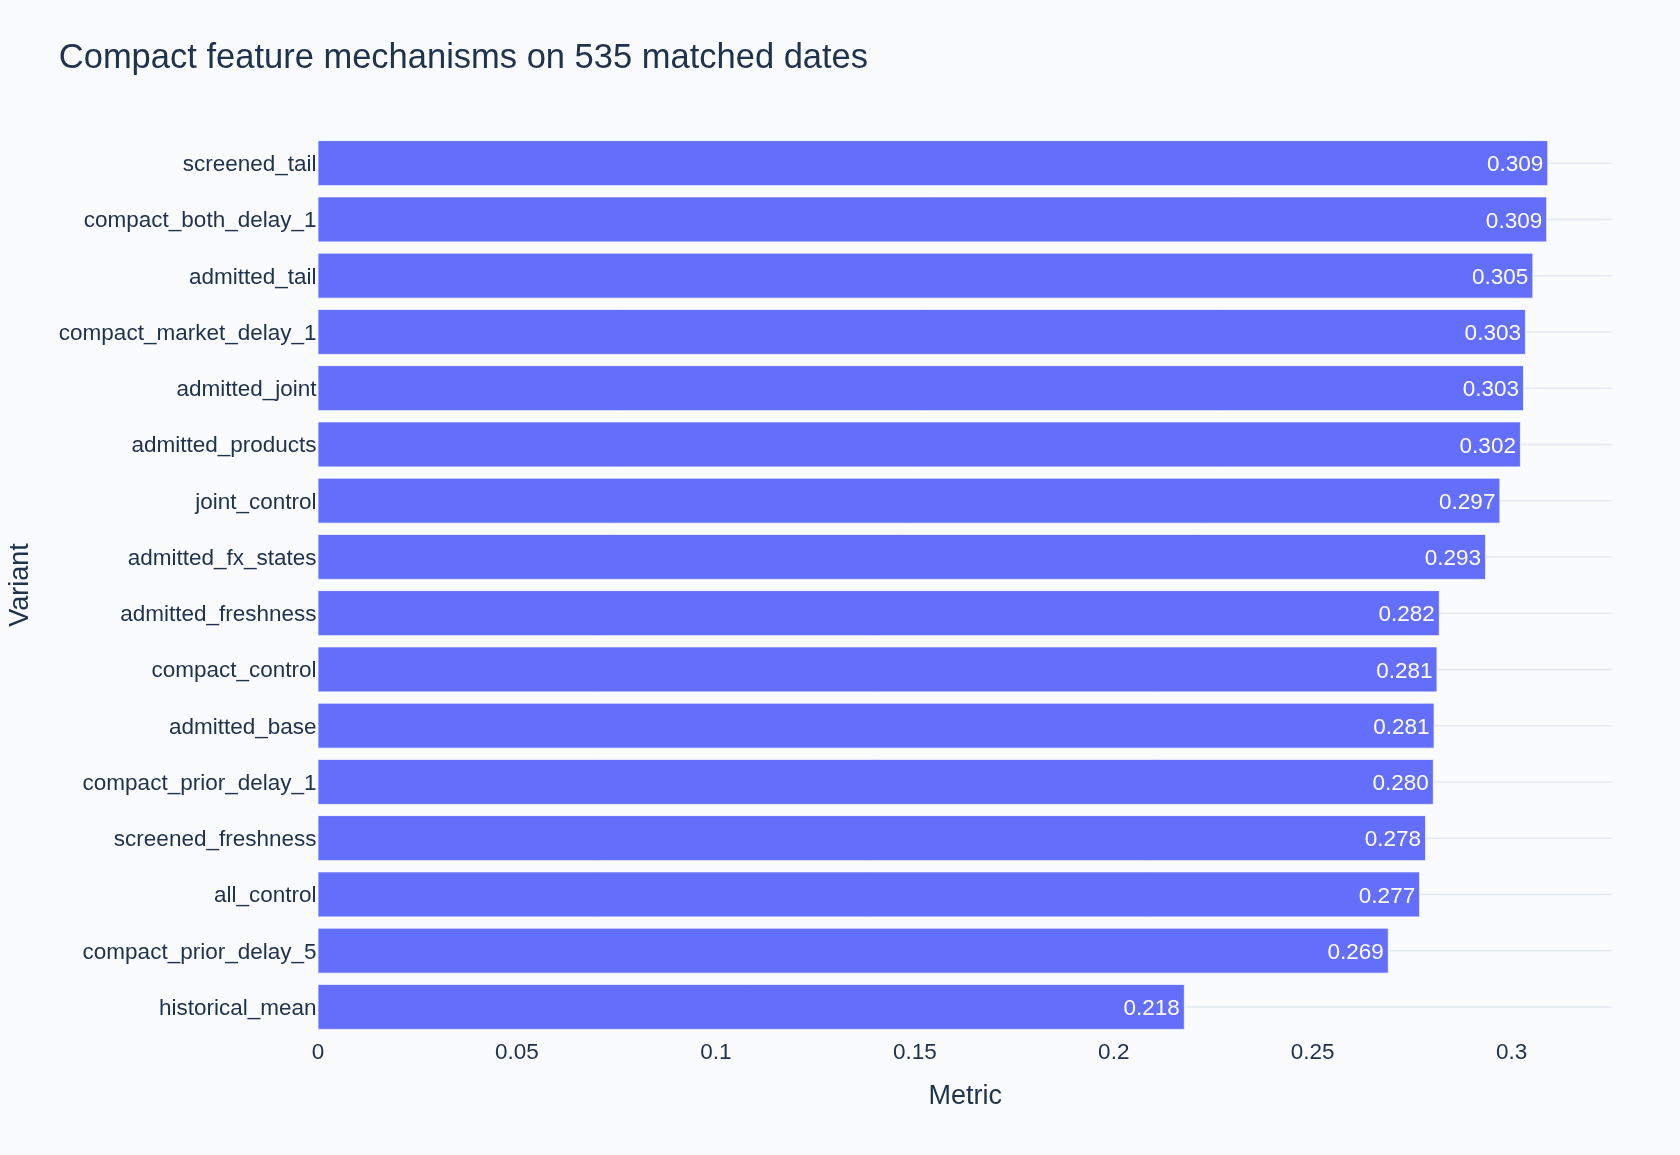

,Variant,Fold,Candidates,Retained,Rejected,Reasons,Product slots,FX state slots
0,screened_tail,1,69,64,5,"{'correlated': 2, 'feature_budget': 3}",0,0
1,screened_freshness,1,51,46,5,{'correlated': 5},0,0
2,admitted_base,1,39,39,0,{},0,0
3,admitted_tail,1,69,69,0,{},0,0
4,admitted_freshness,1,51,51,0,{},0,0
5,admitted_joint,1,81,81,0,{},0,0
6,compact_prior_delay_1,1,81,64,17,"{'correlated': 5, 'feature_budget': 12}",0,0
7,compact_prior_delay_5,1,81,64,17,"{'correlated': 5, 'feature_budget': 12}",0,0
8,compact_market_delay_1,1,81,64,17,"{'correlated': 4, 'feature_budget': 13}",0,0
9,compact_both_delay_1,1,81,64,17,"{'correlated': 4, 'feature_budget': 13}",0,0


In [24]:
from scripts.notebook_support import checked_compact
compact = checked_compact(root)
display(Markdown(f"**Verified compact study:** `{compact['lineage'][:16]}` · {compact['new_fitted_models']} fits · {compact['checkpoint_count']} sealed stages · exact replay error {compact['maximum_prediction_replay_error']:.1e}"))
rows = [{"Variant":n,"Metric":s["official_metric"],"Fold 1":s["fold_scores"][0],"Fold 2":s["fold_scores"][1],"Fold 3":s["fold_scores"][2]} for n,s in compact["summaries"].items()]
scores = pd.DataFrame(rows)
display(scores.set_index("Variant").round(6))
fig = px.bar(scores.sort_values("Metric"),x="Metric",y="Variant",orientation="h",text_auto=".3f",title="Compact feature mechanisms on 535 matched dates")
show_figure(fig,root,"compact_scores",770)
screening = pd.DataFrame([{"Variant":r["variant"],"Fold":r["fold"]+1,"Candidates":r["selection"]["candidate_templates"],"Retained":r["selection"]["retained_templates"],"Rejected":r["selection"]["rejected_templates"],"Reasons":r["selection"]["rejection_reasons"],"Product slots":sum(n.startswith("mechanism_products__") for n in r["selection"]["selected_names"]),"FX state slots":sum(n.startswith("fx_states__") for n in r["selection"]["selected_names"])} for r in compact["results"]])
display(screening)

### Matched contrasts and uncertainty

The two screened component tests compare against the frozen reference-plus-priors control; removing each component from the earlier joint lead reveals conditional contribution. The admitted four-way design compares the base, tail, freshness, and joint panels without a relevance-budget bottleneck. Product and FX-state additions compare against the admitted joint panel. Extra prior delays of one/five dates start **after** the original horizon+1 label release; market delays affect dynamic market features only. The compound one-date test shifts each dynamic family exactly once and preserves static metadata.

All new contrasts join the existing 204 domain comparisons, with 2,000 paired block bootstrap replications at 10, 20, and 40 dates. Simultaneous bounds control the declared comparison family conditional on these fitted models. They do not account for every adaptive research decision or create independent confirmation.

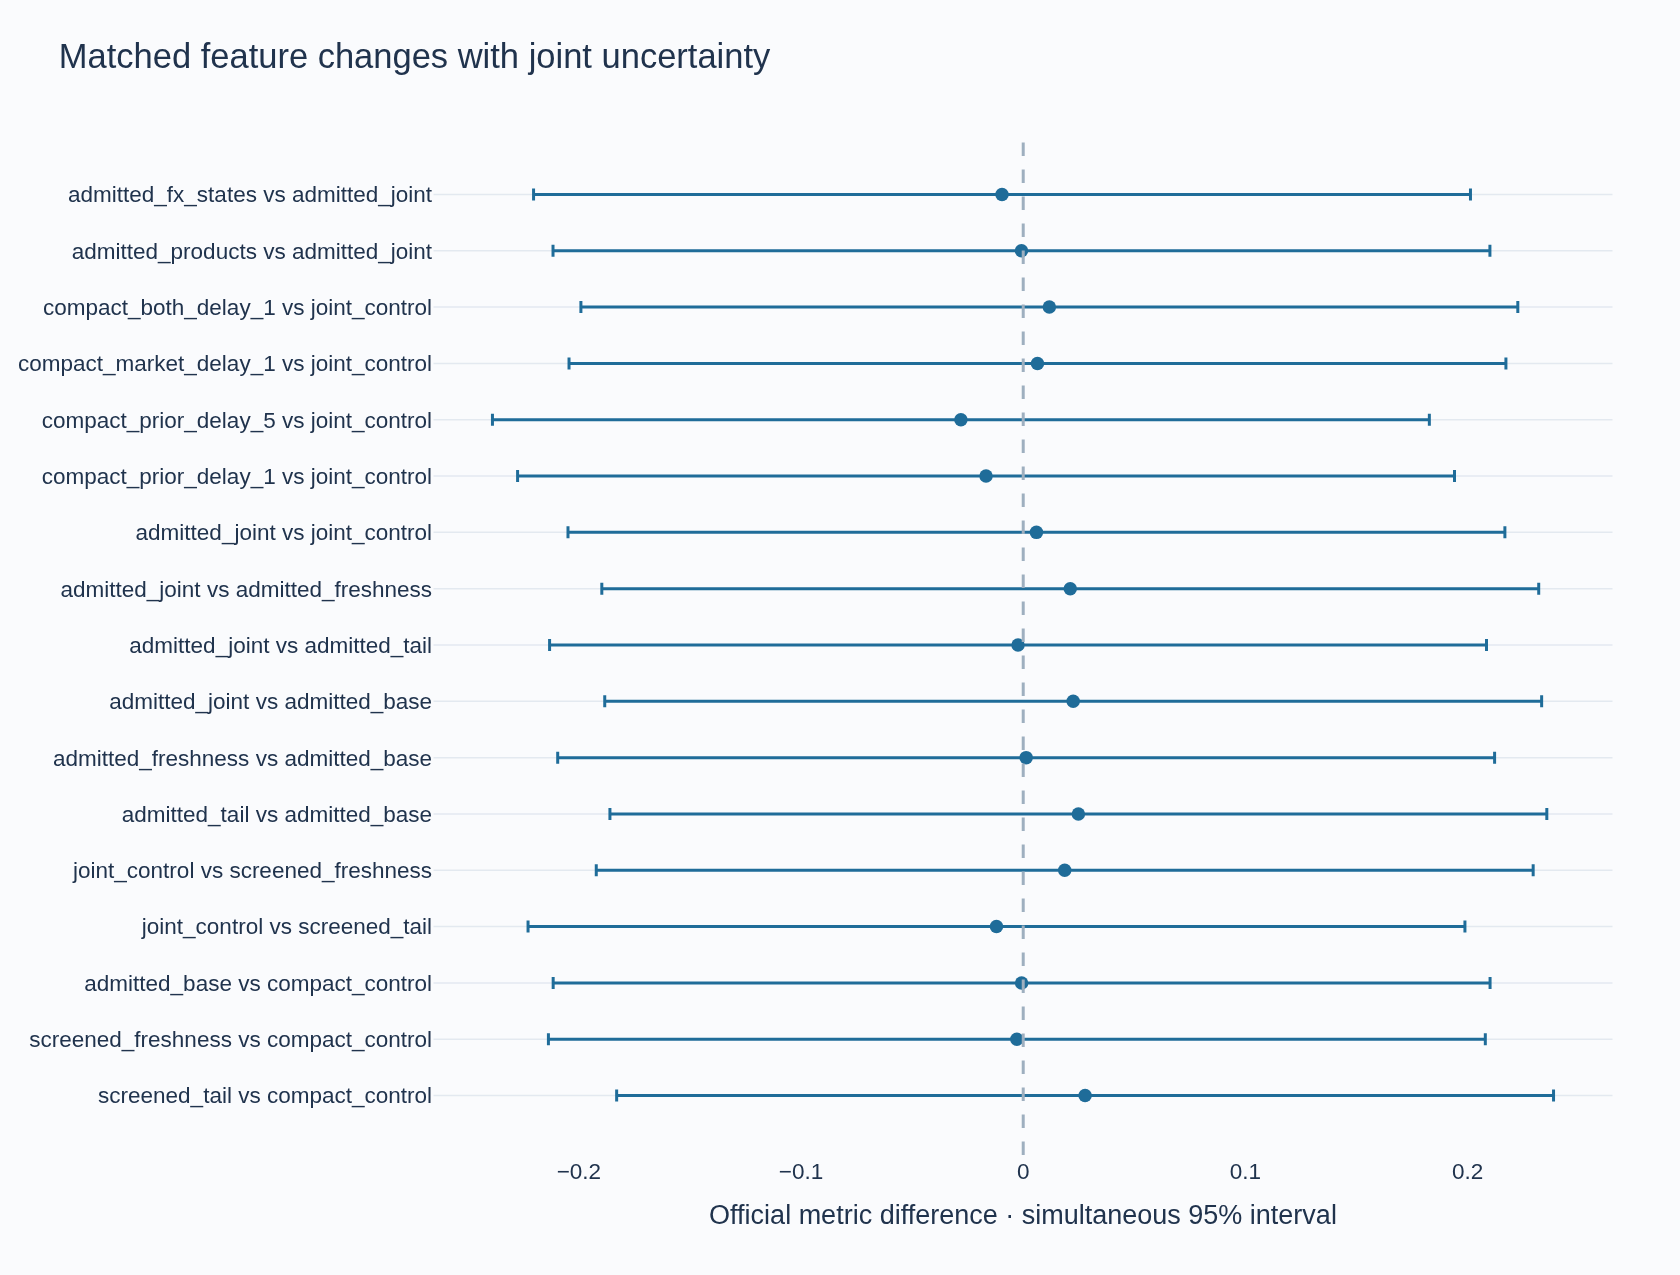

,Contrast,delta,conditional_95_interval,simultaneous_95_interval
0,screened_tail vs compact_control,0.027851,"[-0.015024252226928471, 0.06851763850134754]","[-0.18299226887136016, 0.23869356743493636]"
1,screened_freshness vs compact_control,-0.002861,"[-0.055489211046665425, 0.045750696419142124]","[-0.21370366640082678, 0.20798216990546975]"
2,admitted_base vs compact_control,-0.000724,"[-0.007873505338176401, 0.007301257645564387]","[-0.2115670902344967, 0.2101187460717998]"
3,joint_control vs screened_tail,-0.012033,"[-0.044962731704157835, 0.019622486293660042]","[-0.22287604585367193, 0.1988097904526246]"
4,joint_control vs screened_freshness,0.018678,"[-0.01767872181580852, 0.05507188620128158]","[-0.19216464832420532, 0.2295211879820912]"
5,admitted_tail vs admitted_base,0.024823,"[-0.01134867574979977, 0.060031441905212785]","[-0.1860202319844843, 0.23566560432181222]"
6,admitted_freshness vs admitted_base,0.001317,"[-0.04873614465667287, 0.05043603419831098]","[-0.20952619224722702, 0.2121596440590695]"
7,admitted_joint vs admitted_base,0.022488,"[-0.02353205451220355, 0.06731594441715624]","[-0.18835497835800313, 0.2333308579482934]"
8,admitted_joint vs admitted_tail,-0.002335,"[-0.03460221498853166, 0.02805468366216865]","[-0.2131776645266671, 0.20850817177962944]"
9,admitted_joint vs admitted_freshness,0.021171,"[-0.015320095825947108, 0.05810112232135249]","[-0.18967170426392438, 0.23201413204237215]"


**233 joint comparisons.** Positive simultaneous lower bounds by block length: **{10: 0, 20: 0, 40: 0}**. These are exploratory development results; the final test remains untouched.

In [25]:
matched = pd.DataFrame([r for r in compact["comparisons"] if r["block_dates"] == 20 and r["reference"] != "historical_mean"])
matched["Contrast"] = matched.variant + " vs " + matched.reference
fig = go.Figure(go.Scatter(x=matched.delta,y=matched.Contrast,mode="markers",marker={"size":9,"color":"#1F6C99"},error_x={"type":"data","symmetric":False,"array":[b[1]-d for b,d in zip(matched.simultaneous_95_interval,matched.delta)],"arrayminus":[d-b[0] for b,d in zip(matched.simultaneous_95_interval,matched.delta)]}))
fig.add_vline(x=0,line_dash="dash",line_color="#9EAFBF")
fig.update_layout(title="Matched feature changes with joint uncertainty",xaxis_title="Official metric difference · simultaneous 95% interval")
show_figure(fig,root,"compact_uncertainty",850)
display(matched[["Contrast","delta","conditional_95_interval","simultaneous_95_interval"]])
positive = {b:sum(r["simultaneous_95_interval"][0]>0 for r in compact["joint_comparisons"] if r["block_dates"]==b) for b in [10,20,40]}
display(Markdown(f"**{compact['joint_comparison_count']} joint comparisons.** Positive simultaneous lower bounds by block length: **{positive}**. These are exploratory development results; the final test remains untouched."))

### Economic interpretation and remaining limitations

Tail-risk inputs describe recent shocks, downside variation, and path extremes; freshness inputs describe missing/stale observations and resumption. Their interaction is plausible because a large recorded move can reflect either new information or accumulated price adjustment. This is a hypothesis about this panel, not a claim that missing observations measure tradable liquidity.

FX conditioning follows a concrete market distinction: [BIS research on fragmented FX execution](https://www.bis.org/publications/qr-201912/fx-trade-execution-complex-and-highly-fragmented) describes dispersed venues, dealer internalisation, and incomplete visibility of activity. Those observations motivate allowing different state responses. They do not validate this feature formula. No order-book depth, true FX volume, physical inventory, or historical macro vintage is created by a metadata gate.

Descriptive group changes below use the same truth-only eligibility rule as the preceding analysis. Market groups overlap; one-target horizon rankings remain undefined. The research ledger records results, failures, timing assumptions, and the remaining feature-gate requirements.

Group,FX_involved,JPX_involved,LME_involved,US_involved,paired,single
Variant,,,,,,
admitted_base,0.1983,0.2825,0.1894,0.2103,0.2793,0.0975
admitted_freshness,0.2416,0.3035,0.1815,0.1912,0.2806,0.1089
admitted_fx_states,0.2398,0.2892,0.2116,0.2068,0.2921,0.0988
admitted_joint,0.2522,0.3071,0.2146,0.2137,0.3015,0.1076
admitted_products,0.2427,0.3113,0.2134,0.2228,0.3008,0.1036
admitted_tail,0.2359,0.3001,0.2198,0.2244,0.3034,0.0991


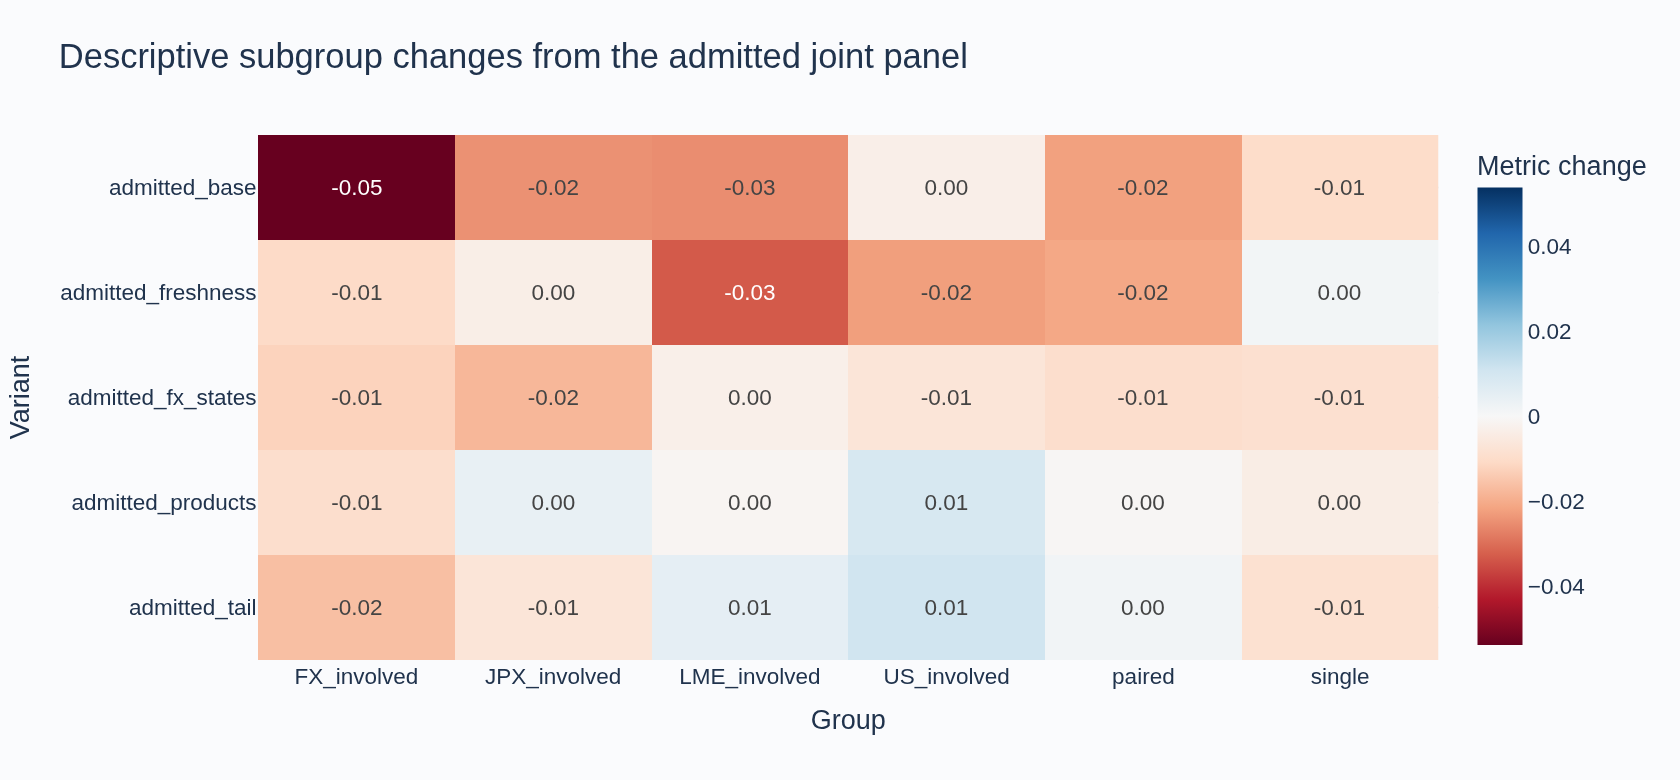

**Feature gate: open.** Preserve failed hypotheses and valid checkpoints. Evaluate fold stability and matched uncertainty before proposing any feature promotion. More columns, an improved aggregate score, or one favorable subgroup does not establish completion.

In [26]:
groups = []
for n in ["admitted_base","admitted_tail","admitted_freshness","admitted_joint","admitted_products","admitted_fx_states"]:
    for group,s in compact["summaries"][n]["subgroups"].items():
        groups.append({"Variant":n,"Group":group,"Metric":s["official_metric"],"Eligible dates":s["eligible_dates"],"Excluded dates":s["excluded_dates"]})
group_table = pd.DataFrame(groups).pivot(index="Variant",columns="Group",values="Metric")
display(group_table.round(4))
deltas = group_table.sub(group_table.loc["admitted_joint"],axis=1).drop(index="admitted_joint")
fig = px.imshow(deltas,color_continuous_scale="RdBu",color_continuous_midpoint=0,text_auto=".2f",aspect="auto",title="Descriptive subgroup changes from the admitted joint panel",labels={"color":"Metric change"})
show_figure(fig,root,"compact_subgroups",520)
display(Markdown("**Feature gate: open.** Preserve failed hypotheses and valid checkpoints. Evaluate fold stability and matched uncertainty before proposing any feature promotion. More columns, an improved aggregate score, or one favorable subgroup does not establish completion."))

## Do historical priors depend on the risk state?

The compact study left a concrete question: does a historical mean have different short-horizon relevance when risk is rising, falling, or unusually high? [Moreira and Muir (2017)](https://onlinelibrary.wiley.com/doi/10.1111/jofi.12513) find that expected returns need not change proportionally with volatility in their studied portfolios. That motivates this conditional-feature hypothesis; it does not validate these formulas or turn this ranking metric into trading performance.

**34 new templates:** six bounded risk states, four risk-normalized historical priors, and 24 state-by-prior products. States describe 63/252 and 126/252 risk ratios, five- and 21-date risk changes, 21-date risk instability, and a trailing 126-date percentile. Products keep their state and prior main effects. All inputs descend from the frozen, horizon+1-delayed prior features. Rolling windows end at the current prediction origin. The delay stress adds another date to those inputs before recomputing every derived feature.

**Eight variants × three purged folds = 24 fits.** Frozen tree settings and matched admission controls isolate feature changes. Existing checkpoints are reused. This is exploratory research following the earlier 233 domain comparisons; the final 247 origins remain untouched.

**Verified risk-state lineage:** `bdf288bea624a488` · 24 fitted models · 25 sealed stages · replay error 0.0e+00

,Metric,Fold 1,Fold 2,Fold 3
Variant,,,,
admitted_base,0.280513,0.337542,0.154580,0.352277
admitted_joint,0.303001,0.363156,0.164274,0.400578
admitted_tail,0.305336,0.390579,0.152341,0.399881
base_state_products,0.291457,0.357961,0.176080,0.345744
delayed_state_products,0.286221,0.378322,0.121784,0.381642
historical_mean,0.217739,0.162550,0.182488,0.296861
joint_state_products,0.287788,0.334708,0.169897,0.371803
screened_state_products,0.278565,0.340575,0.136882,0.372019
screened_tail,0.309088,0.405901,0.154856,0.400172


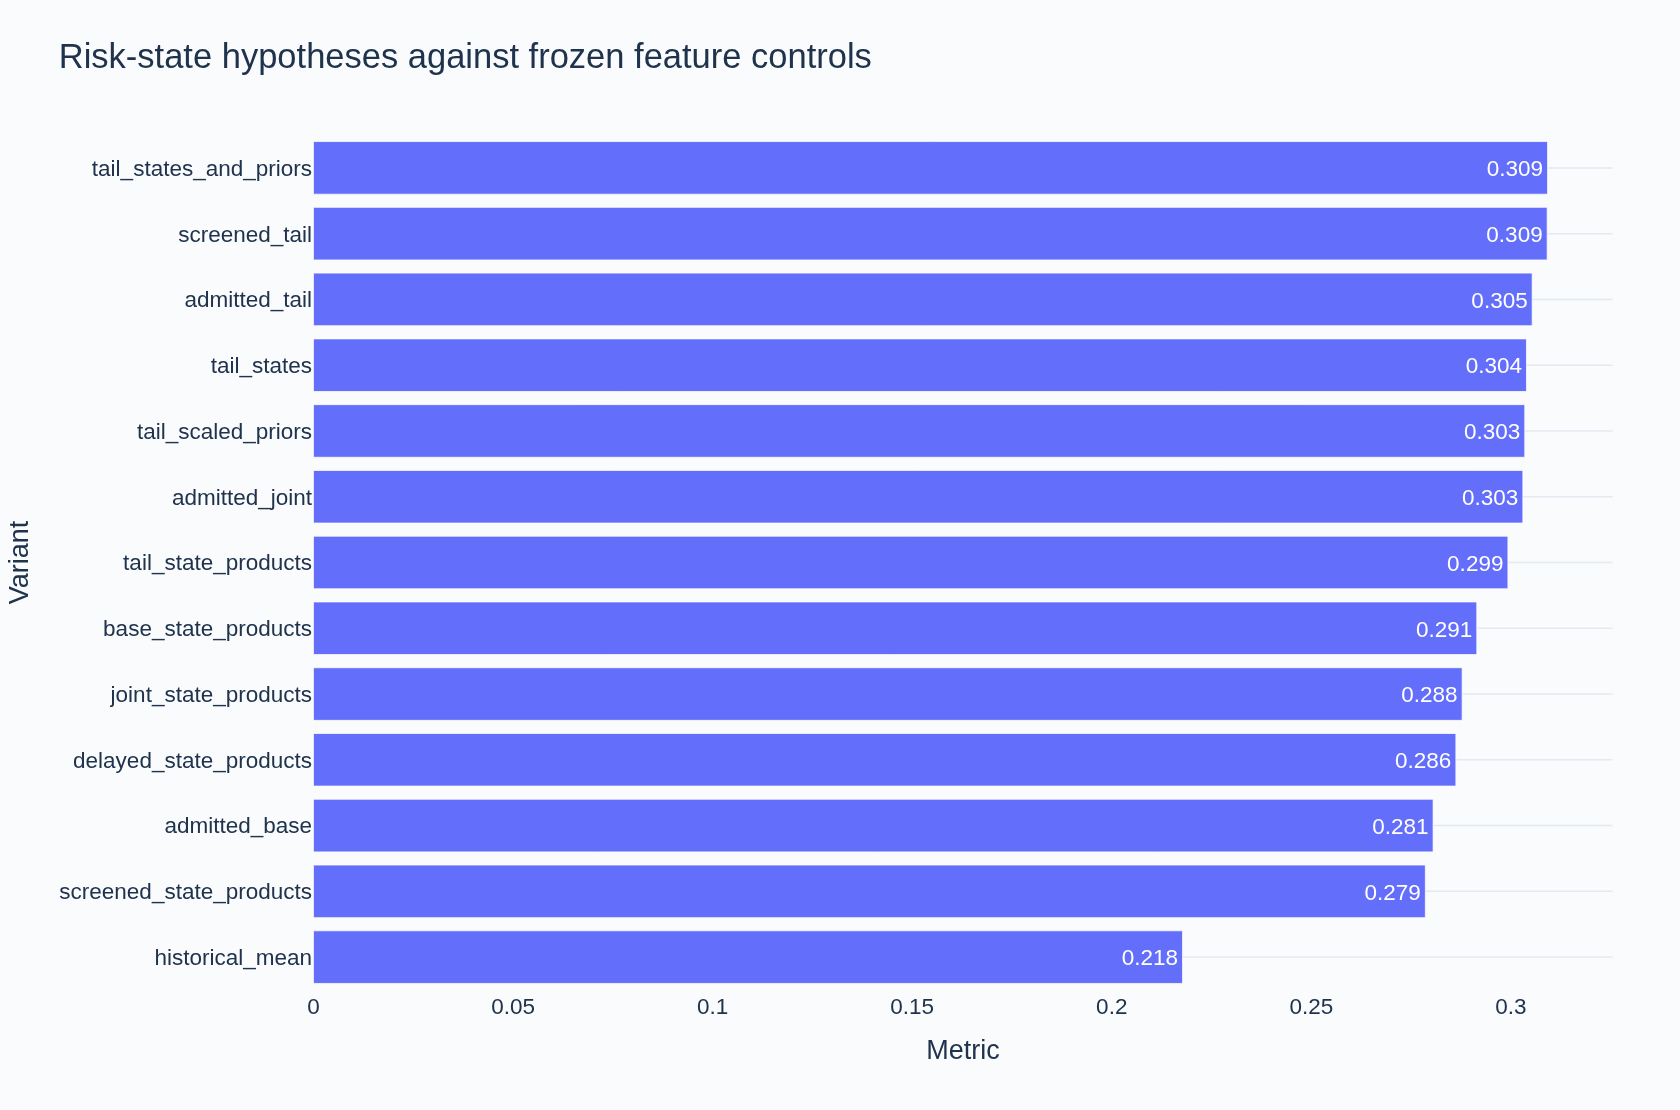

,Variant,Fold,Candidates,Retained,Rejected,Reasons,Retained products
0,tail_states,1,75,75,0,{},0
1,tail_states,2,75,75,0,{},0
2,tail_states,3,75,75,0,{},0
3,tail_scaled_priors,1,73,73,0,{},0
4,tail_scaled_priors,2,73,73,0,{},0
5,tail_scaled_priors,3,73,73,0,{},0
6,tail_states_and_priors,1,79,79,0,{},0
7,tail_states_and_priors,2,79,79,0,{},0
8,tail_states_and_priors,3,79,79,0,{},0
9,tail_state_products,1,103,103,0,{},24


In [27]:
from scripts.notebook_support import checked_risk_state
risk_state = checked_risk_state(root)
display(Markdown(f"**Verified risk-state lineage:** `{risk_state['lineage'][:16]}` · {risk_state['new_fitted_models']} fitted models · {risk_state['checkpoint_count']} sealed stages · replay error {risk_state['maximum_prediction_replay_error']:.1e}"))
rows = [{"Variant": n, "Metric": s["official_metric"], **{f"Fold {i+1}": v for i,v in enumerate(s["fold_scores"])}} for n,s in risk_state["summaries"].items()]
state_scores = pd.DataFrame(rows).set_index("Variant")
display(state_scores.round(6))
fig = px.bar(state_scores.sort_values("Metric").reset_index(), x="Metric", y="Variant", orientation="h", text_auto=".3f", title="Risk-state hypotheses against frozen feature controls")
show_figure(fig, root, "risk_state_scores", 740)
counts = pd.DataFrame([{"Variant": r["variant"], "Fold": r["fold"]+1, "Candidates": r["selection"]["candidate_templates"], "Retained": r["selection"]["retained_templates"], "Rejected": r["selection"]["rejected_templates"], "Reasons": r["selection"]["rejection_reasons"], "Retained products": sum(n.startswith("state_prior_product__") for n in r["selection"]["selected_names"])} for r in risk_state["results"]])
display(counts)

### Attribute gains to features and inspect temporal failures

States, normalized priors, and their combination are compared with the admitted tail-risk control. Adding the 24 products is compared with the same state and prior main effects. Removing tail risk, adding freshness, screening to 64 columns, and adding an information delay test separate explanations. The same tree settings apply throughout. Per-fold results describe stability; they do not authorize choosing a special model for the weakest fold.

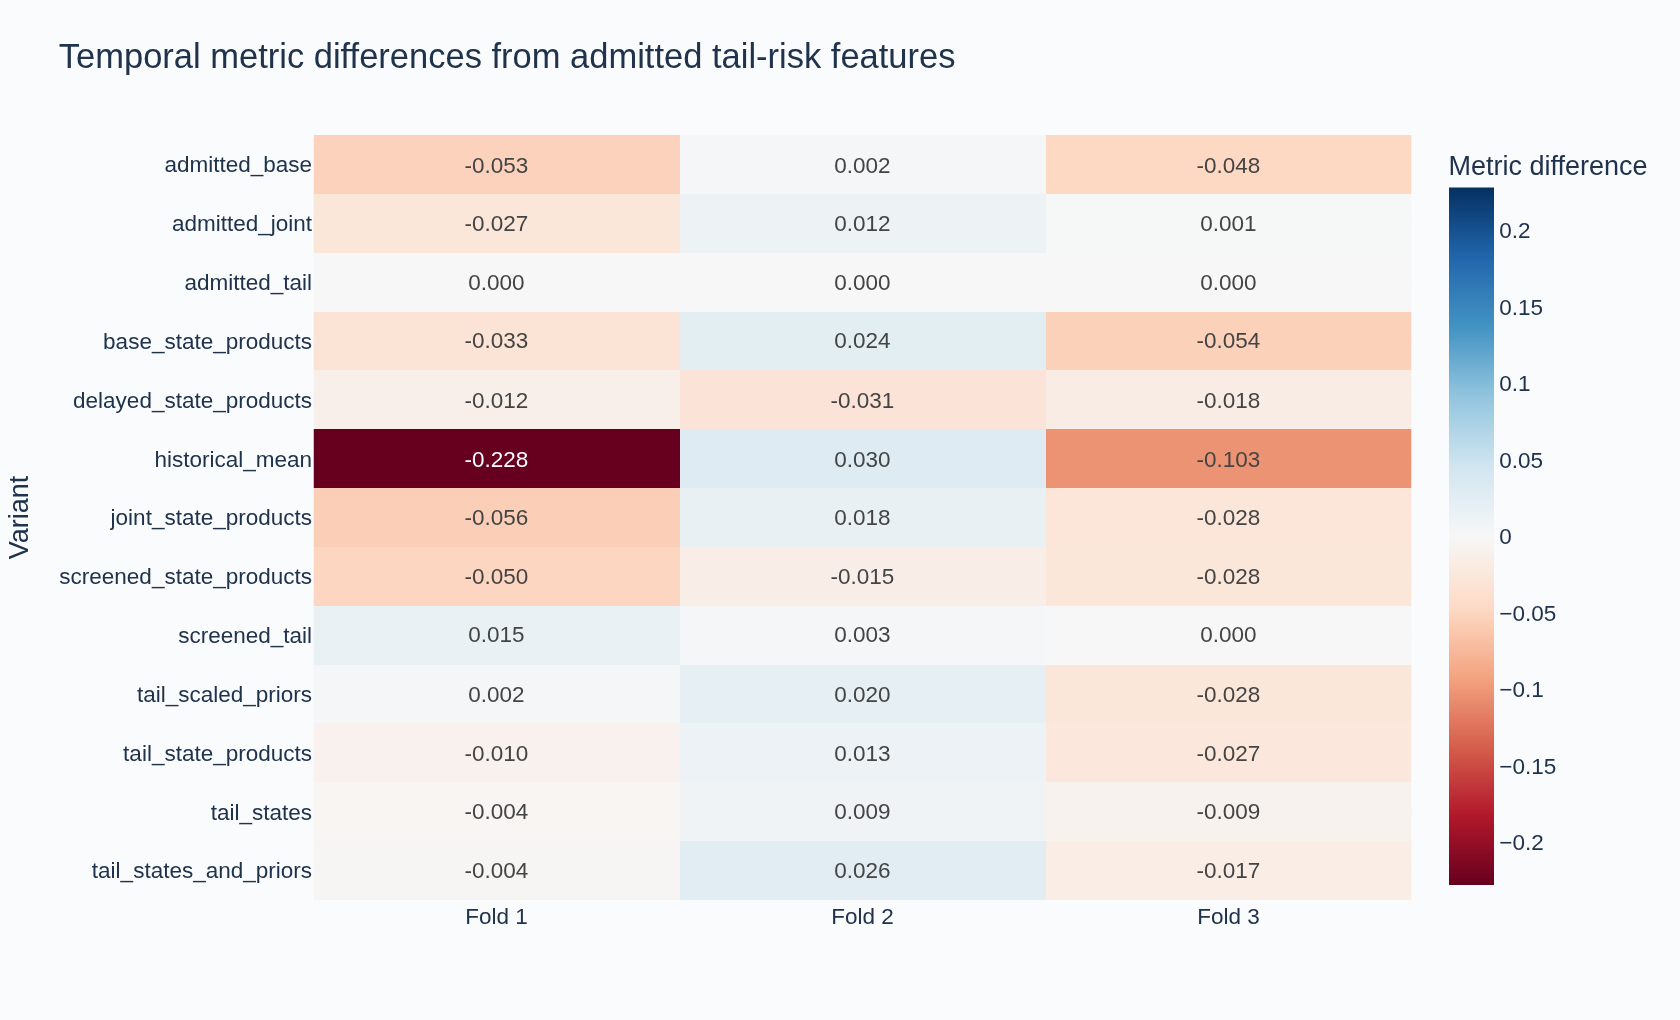

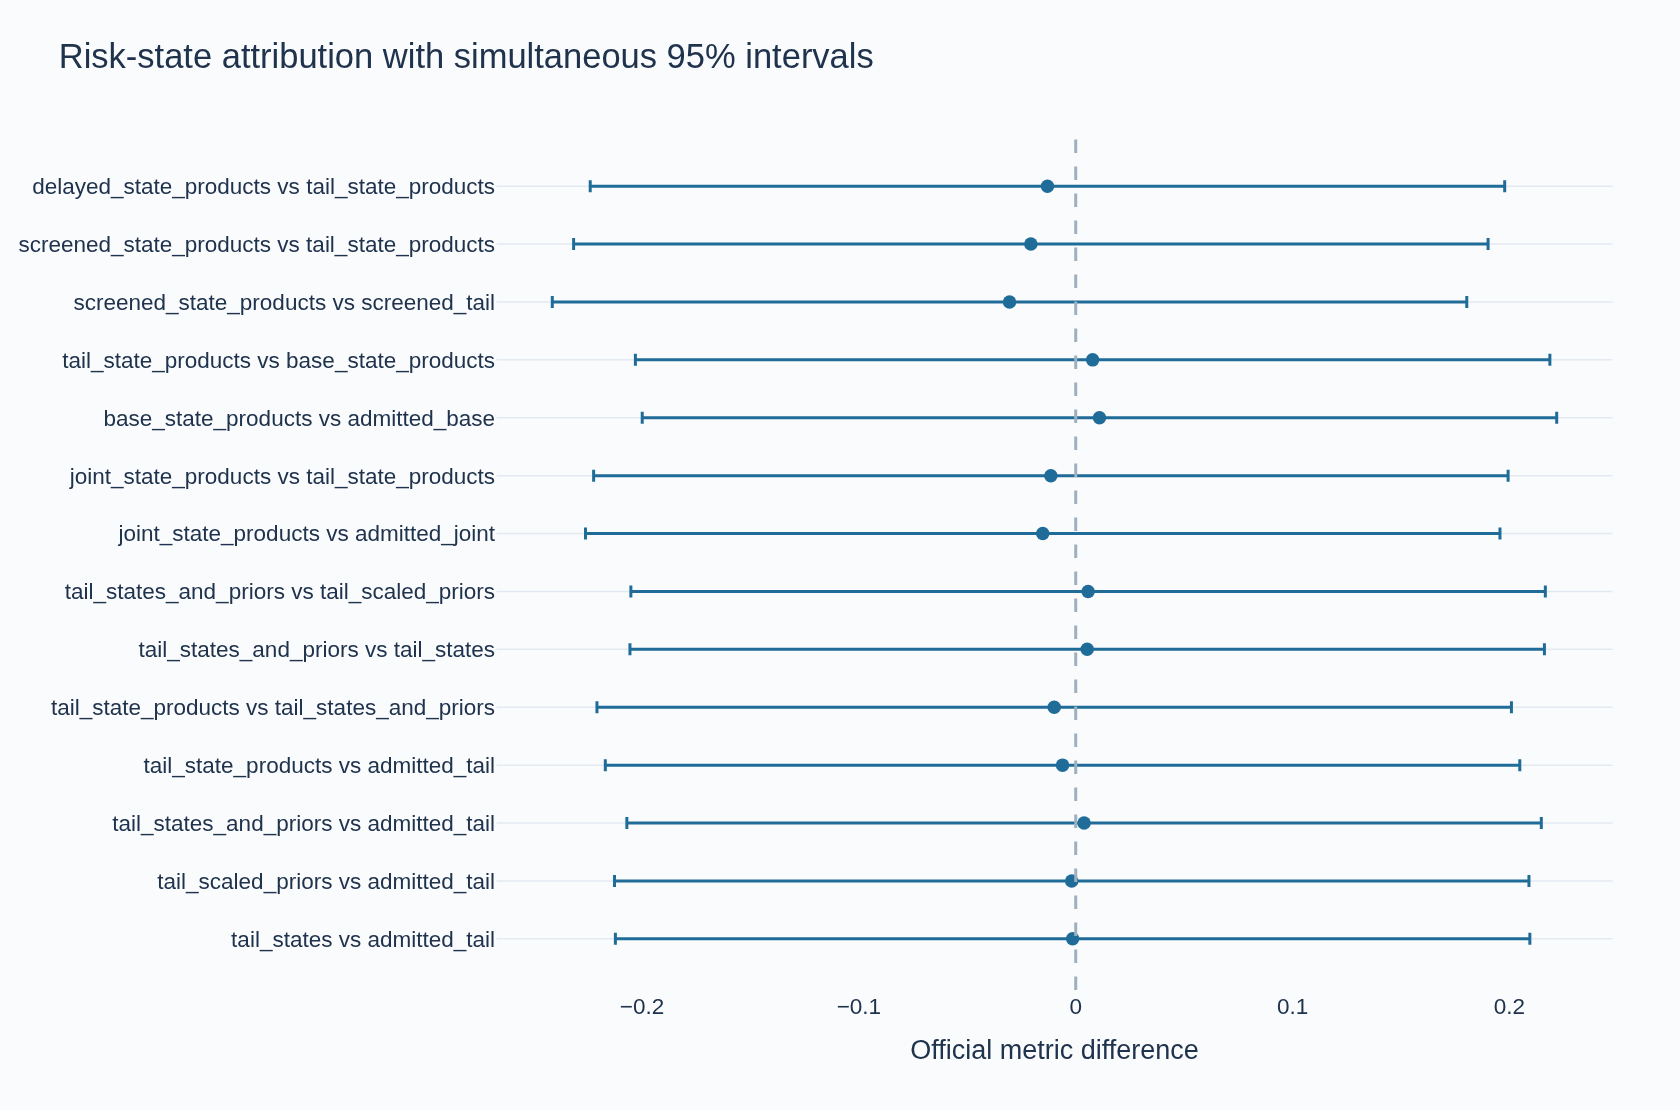

,Contrast,delta,conditional_95_interval,simultaneous_95_interval
0,tail_states vs admitted_tail,-0.001434,"[-0.021416329661153057, 0.018509543986049114]","[-0.2122765849839941, 0.20940925132230243]"
1,tail_scaled_priors vs admitted_tail,-0.001854,"[-0.01484007159985313, 0.01130890489206914]","[-0.21269704261242245, 0.20898879369387408]"
2,tail_states_and_priors vs admitted_tail,0.003851,"[-0.014863878298583565, 0.02187632891448178]","[-0.20699238431160427, 0.21469345199469225]"
3,tail_state_products vs admitted_tail,-0.006079,"[-0.0441175902036859, 0.036391188099505124]","[-0.21692184559127914, 0.20476399071501739]"
4,tail_state_products vs tail_states_and_priors,-0.009929,"[-0.03909391667534504, 0.02253858313649033]","[-0.22077237943282313, 0.2009134568734734]"
5,tail_states_and_priors vs tail_states,0.005284,"[-0.009827741769857137, 0.022409474754129244]","[-0.20555871748075843, 0.2161271188255381]"
6,tail_states_and_priors vs tail_scaled_priors,0.005705,"[-0.008627459952687579, 0.019827720984958462]","[-0.20513825985233008, 0.21654757645396644]"
7,joint_state_products vs admitted_joint,-0.015213,"[-0.053963456760222024, 0.028488884001643098]","[-0.22605581682440024, 0.1956300194818963]"
8,joint_state_products vs tail_state_products,-0.011469,"[-0.04691757561938648, 0.021638516014231376]","[-0.22231163575978818, 0.19937420054650834]"
9,base_state_products vs admitted_base,0.010944,"[-0.028842972489787472, 0.05512427764520691]","[-0.19989846319627624, 0.22178737311002028]"


**255 joint comparisons** across five domain phases. Positive simultaneous lower bounds: **{10: 0, 20: 0, 40: 0}**. Bounds condition on fitted models and do not undo the adaptive research history.

In [28]:
folds_only = state_scores[["Fold 1","Fold 2","Fold 3"]]
fold_deltas = folds_only.sub(folds_only.loc["admitted_tail"],axis=1)
fig = px.imshow(fold_deltas, color_continuous_scale="RdBu", color_continuous_midpoint=0, text_auto=".3f", aspect="auto", title="Temporal metric differences from admitted tail-risk features", labels={"color":"Metric difference"})
show_figure(fig, root, "risk_state_folds", 680)
contrasts = pd.DataFrame([r for r in risk_state["comparisons"] if r["block_dates"] == 20 and r["reference"] != "historical_mean"])
contrasts["Contrast"] = contrasts.variant + " vs " + contrasts.reference
fig = go.Figure(go.Scatter(x=contrasts.delta, y=contrasts.Contrast, mode="markers", marker={"size":9,"color":"#1F6C99"}, error_x={"type":"data","symmetric":False,"array":[b[1]-d for b,d in zip(contrasts.simultaneous_95_interval,contrasts.delta)],"arrayminus":[d-b[0] for b,d in zip(contrasts.simultaneous_95_interval,contrasts.delta)]}))
fig.add_vline(x=0,line_dash="dash",line_color="#9EAFBF")
fig.update_layout(title={"text":"Risk-state attribution with simultaneous 95% intervals","xanchor":"left","xref":"container"},xaxis_title="Official metric difference")
show_figure(fig,root,"risk_state_uncertainty",740)
display(contrasts[["Contrast","delta","conditional_95_interval","simultaneous_95_interval"]])
positive = {b:sum(r["simultaneous_95_interval"][0]>0 for r in risk_state["joint_comparisons"] if r["block_dates"]==b) for b in [10,20,40]}
display(Markdown(f"**{risk_state['joint_comparison_count']} joint comparisons** across five domain phases. Positive simultaneous lower bounds: **{positive}**. Bounds condition on fitted models and do not undo the adaptive research history."))

### Completion gate

These experiments turn another plausible mechanism into measurable evidence, including negative results. A feature-count increase or a better pooled point estimate is insufficient to close the gate. The middle period, multiple-comparison uncertainty, and the lack of independent confirmation remain explicit. True futures carry, inventories, macro surprises, seasonality, weather, and text still require verified calendar/instrument mappings and historical release vintages that have not been established for the supplied anonymous date panel. Final optimization and final-test evaluation remain gated.